In [228]:
!pip install xgboost

In [346]:
!pip install shap

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 6.6 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [347]:
import pandas as pd  # Data preprocessing
import numpy as np
import matplotlib.pyplot as plt  # Data viz
import seaborn as sns # Data viz
import missingno as msno #Missing data - Data visualisation
from xgboost import XGBRegressor
import shap


In [230]:
# Load your csv files

claims = pd.read_csv("claims.csv")
policyholders = pd.read_csv("policyholders.csv")
thirdparty = pd.read_csv("third_parties.csv")

### Inspect Datasets

In [231]:
claims.head()

,Claim_ID,Policy_ID,Accident_Date,FNOL_Date,Claim_Type,Claim_Complexity,Fraud_Flag,Litigation_Flag,Estimated_Claim_Amount,Ultimate_Claim_Amount,Severity_Band,Settlement_Date,Status
0,CLM30000,POL14506,2019-12-19,2019-12-19,Theft,Medium,False,True,5243,2808.0,Minor,2020-03-01,settled
1,CLM30001,POL14338,2018-12-30,2018-12-31,Collision,Low,False,False,3934,2952.0,Minor,2019-03-23,settled
2,CLM30002,POL13575,2021-10-19,2021-10-19,Other,Medium,False,False,153631,156497.0,Catastrophic,2022-04-22,settled
3,CLM30003,POL10138,2021-06-18,2021-06-18,Weather,Low,False,False,2812,1450.0,Minor,2021-09-13,settled
4,CLM30004,POL12316,2021-03-21,2021-03-24,Theft,Low,False,False,5094,4243.0,Minor,2021-05-26,settled


In [232]:
policyholders.head()

,Policy_ID,Customer_ID,Age_of_Driver,Gender,Occupation,Region,Annual_Mileage,Driving_Experience_Years,Vehicle_Type,Vehicle_Age,Credit_Score_Band
0,POL10000,CUST20000,56,Female,Retired,Newcastle,7552,36,Sedan,10,Fair
1,POL10001,CUST20001,53,Female,Unemployed,Bristol,13275,31,Motorcycle,11,Poor
2,POL10002,CUST20002,19,Female,Unemployed,London,12967,0,Sedan,9,Excellent
3,POL10003,CUST20003,77,Female,Retired,Birmingham,4346,56,Hatchback,2,Fair
4,POL10004,CUST20004,24,Male,Employed,Manchester,9598,2,Sedan,14,Good


In [233]:
thirdparty.head()

,Claim_ID,TP_ID,ThirdParty_Role,TP_Injury_Severity
0,CLM30000,TP40000,Pedestrian,Minor
1,CLM30002,TP40001,Passenger,Minor
2,CLM30007,TP40002,Pedestrian,Minor
3,CLM30012,TP40003,Pedestrian,Minor
4,CLM30015,TP40004,Driver,Minor


In [234]:
claims.dtypes

Claim_ID                   object
Policy_ID                  object
Accident_Date              object
FNOL_Date                  object
Claim_Type                 object
Claim_Complexity           object
Fraud_Flag                   bool
Litigation_Flag              bool
Estimated_Claim_Amount      int64
Ultimate_Claim_Amount     float64
Severity_Band              object
Settlement_Date            object
Status                     object
dtype: object

In [235]:
policyholders.dtypes

Policy_ID                   object
Customer_ID                 object
Age_of_Driver                int64
Gender                      object
Occupation                  object
Region                      object
Annual_Mileage               int64
Driving_Experience_Years     int64
Vehicle_Type                object
Vehicle_Age                  int64
Credit_Score_Band           object
dtype: object

In [236]:
thirdparty.dtypes

Claim_ID              object
TP_ID                 object
ThirdParty_Role       object
TP_Injury_Severity    object
dtype: object

In [237]:
claims.describe()

,Estimated_Claim_Amount,Ultimate_Claim_Amount
count,8.000000e+03,7.575000e+03
mean,1.447988e+04,1.311868e+04
std,3.873981e+04,3.810405e+04
min,5.500000e+02,3.320000e+02
25%,2.205750e+03,1.578000e+03
50%,4.416000e+03,3.409000e+03
75%,1.167475e+04,9.744000e+03
max,1.064239e+06,1.005590e+06


In [238]:
policyholders.describe()

,Age_of_Driver,Annual_Mileage,Driving_Experience_Years,Vehicle_Age
count,5000.0000,5000.000000,5000.000000,5000.0000
mean,48.7524,12125.190800,28.817600,9.9910
std,17.9704,4036.274571,17.919335,6.0998
min,18.0000,500.000000,0.000000,0.0000
25%,33.0000,9388.250000,13.000000,5.0000
50%,49.0000,12082.000000,29.000000,10.0000
75%,65.0000,14860.750000,45.000000,15.0000
max,79.0000,27410.000000,61.000000,20.0000


In [239]:
thirdparty.describe()

,Claim_ID,TP_ID,ThirdParty_Role,TP_Injury_Severity
count,2410,2410,2410,2410
unique,1997,2410,3,3
top,CLM37985,TP42409,Passenger,Minor
freq,2,1,836,2050


In [240]:
claims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Claim_ID                8000 non-null   object 
 1   Policy_ID               8000 non-null   object 
 2   Accident_Date           8000 non-null   object 
 3   FNOL_Date               8000 non-null   object 
 4   Claim_Type              8000 non-null   object 
 5   Claim_Complexity        8000 non-null   object 
 6   Fraud_Flag              8000 non-null   bool   
 7   Litigation_Flag         8000 non-null   bool   
 8   Estimated_Claim_Amount  8000 non-null   int64  
 9   Ultimate_Claim_Amount   7575 non-null   float64
 10  Severity_Band           8000 non-null   object 
 11  Settlement_Date         7575 non-null   object 
 12  Status                  8000 non-null   object 
dtypes: bool(2), float64(1), int64(1), object(9)
memory usage: 703.3+ KB


This suggests that there are missing values on the claims table

In [241]:
policyholders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Policy_ID                 5000 non-null   object
 1   Customer_ID               5000 non-null   object
 2   Age_of_Driver             5000 non-null   int64 
 3   Gender                    5000 non-null   object
 4   Occupation                5000 non-null   object
 5   Region                    5000 non-null   object
 6   Annual_Mileage            5000 non-null   int64 
 7   Driving_Experience_Years  5000 non-null   int64 
 8   Vehicle_Type              5000 non-null   object
 9   Vehicle_Age               5000 non-null   int64 
 10  Credit_Score_Band         5000 non-null   object
dtypes: int64(4), object(7)
memory usage: 429.8+ KB


No missing values on the policyholders table

In [242]:
thirdparty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Claim_ID            2410 non-null   object
 1   TP_ID               2410 non-null   object
 2   ThirdParty_Role     2410 non-null   object
 3   TP_Injury_Severity  2410 non-null   object
dtypes: object(4)
memory usage: 75.4+ KB


No missing Values on the thirdparties table.

#### MAPPING THE SCHEMA

In [243]:
# Validate keys areunique before merging

assert claims["Claim_ID"].is_unique
assert policyholders["Policy_ID"].is_unique


In [244]:
# Encoding injury severity

severity_map = {
    "none": 0,
    "minor": 1,
    "serious": 2,
    "fatal": 3
}

thirdparty["injury_severity_score"] = (
    thirdparty["TP_Injury_Severity"].map(severity_map)
)

In [245]:
# Third party aggregation

third_party_agg = (
    thirdparty
    .groupby("Claim_ID")
    .agg(
        # groups all thirdparties belonging to one claim
        Num_Third_Parties=("TP_ID", "count"),

        # Tells the total number of injuries
        Total_Injuries=("TP_Injury_Severity", lambda x: (x != "none").sum()),

        # Did any thirdparty die
        Any_Fatal_Injury=("injury_severity_score", lambda x: int((x == 3).any()))
    )
    .reset_index()
)


In [246]:
claims_policy = claims.merge(
    policyholders,
    on="Policy_ID",
    how="left",
    validate="many_to_one"
)


In [247]:
final_dataset = claims_policy.merge(
    third_party_agg,
    on="Claim_ID",
    how="left",
    validate="one_to_one"
)


In [248]:
# Claims with no third parties are filled with zero

third_party_cols = [
    "Num_Third_Parties",
    "Total_Injuries",
    "Any_Fatal_Injury"
]

final_dataset[third_party_cols] = (
    final_dataset[third_party_cols].fillna(0)
)


In [249]:
# Integrety check

print("Rows:", final_dataset.shape[0])
print("Unique Claim_ID:", final_dataset["Claim_ID"].nunique())

Rows: 8000
Unique Claim_ID: 8000


### Merged Dataset

In [250]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Claim_ID                  8000 non-null   object 
 1   Policy_ID                 8000 non-null   object 
 2   Accident_Date             8000 non-null   object 
 3   FNOL_Date                 8000 non-null   object 
 4   Claim_Type                8000 non-null   object 
 5   Claim_Complexity          8000 non-null   object 
 6   Fraud_Flag                8000 non-null   bool   
 7   Litigation_Flag           8000 non-null   bool   
 8   Estimated_Claim_Amount    8000 non-null   int64  
 9   Ultimate_Claim_Amount     7575 non-null   float64
 10  Severity_Band             8000 non-null   object 
 11  Settlement_Date           7575 non-null   object 
 12  Status                    8000 non-null   object 
 13  Customer_ID               8000 non-null   object 
 14  Age_of_D

In [251]:
final_dataset.head(50)

,Claim_ID,Policy_ID,Accident_Date,FNOL_Date,Claim_Type,Claim_Complexity,Fraud_Flag,Litigation_Flag,Estimated_Claim_Amount,Ultimate_Claim_Amount,...,Occupation,Region,Annual_Mileage,Driving_Experience_Years,Vehicle_Type,Vehicle_Age,Credit_Score_Band,Num_Third_Parties,Total_Injuries,Any_Fatal_Injury
0,CLM30000,POL14506,2019-12-19,2019-12-19,Theft,Medium,False,True,5243,2808.0,...,Retired,Glasgow,4891,34,Hatchback,6,Excellent,1.0,1.0,0.0
1,CLM30001,POL14338,2018-12-30,2018-12-31,Collision,Low,False,False,3934,2952.0,...,Employed,Newcastle,18408,23,Van,9,Fair,0.0,0.0,0.0
2,CLM30002,POL13575,2021-10-19,2021-10-19,Other,Medium,False,False,153631,156497.0,...,Unemployed,Newcastle,10793,0,SUV,5,Excellent,1.0,1.0,0.0
3,CLM30003,POL10138,2021-06-18,2021-06-18,Weather,Low,False,False,2812,1450.0,...,Employed,Newcastle,9405,5,Hatchback,13,Good,0.0,0.0,0.0
4,CLM30004,POL12316,2021-03-21,2021-03-24,Theft,Low,False,False,5094,4243.0,...,Unemployed,Leeds,16729,9,Hatchback,12,Excellent,0.0,0.0,0.0
5,CLM30005,POL14720,2020-04-12,2020-04-13,Weather,Low,False,False,2568,1796.0,...,Employed,Newcastle,12094,32,Hatchback,12,Excellent,0.0,0.0,0.0
6,CLM30006,POL14632,2019-11-12,2019-11-15,Weather,Medium,False,False,18782,18386.0,...,Employed,Liverpool,11632,14,Hatchback,7,Excellent,0.0,0.0,0.0
7,CLM30007,POL12314,2024-10-30,2024-11-02,Fire,Low,False,False,15957,13825.0,...,Self-Employed,Bristol,14576,45,Sedan,3,Excellent,1.0,1.0,0.0
8,CLM30008,POL13933,2019-09-10,2019-09-14,Vandalism,Medium,False,False,1357,1013.0,...,Employed,Bristol,7822,36,Coupe,1,Fair,0.0,0.0,0.0
9,CLM30009,POL11507,2025-05-03,2025-05-04,Collision,Low,False,False,2799,1781.0,...,Employed,Cardiff,16896,7,Van,5,Fair,0.0,0.0,0.0


In [252]:
# Check for duplicates

final_dataset.duplicated().sum()

np.int64(0)

In [253]:
# Check for null values

null_vals = final_dataset.isnull().sum()
null_vals

Claim_ID                      0
Policy_ID                     0
Accident_Date                 0
FNOL_Date                     0
Claim_Type                    0
Claim_Complexity              0
Fraud_Flag                    0
Litigation_Flag               0
Estimated_Claim_Amount        0
Ultimate_Claim_Amount       425
Severity_Band                 0
Settlement_Date             425
Status                        0
Customer_ID                   0
Age_of_Driver                 0
Gender                        0
Occupation                    0
Region                        0
Annual_Mileage                0
Driving_Experience_Years      0
Vehicle_Type                  0
Vehicle_Age                   0
Credit_Score_Band             0
Num_Third_Parties             0
Total_Injuries                0
Any_Fatal_Injury              0
dtype: int64

In [254]:
# % of missing values

final_dataset["Ultimate_Claim_Amount"].isna().mean() * 100

np.float64(5.3125)

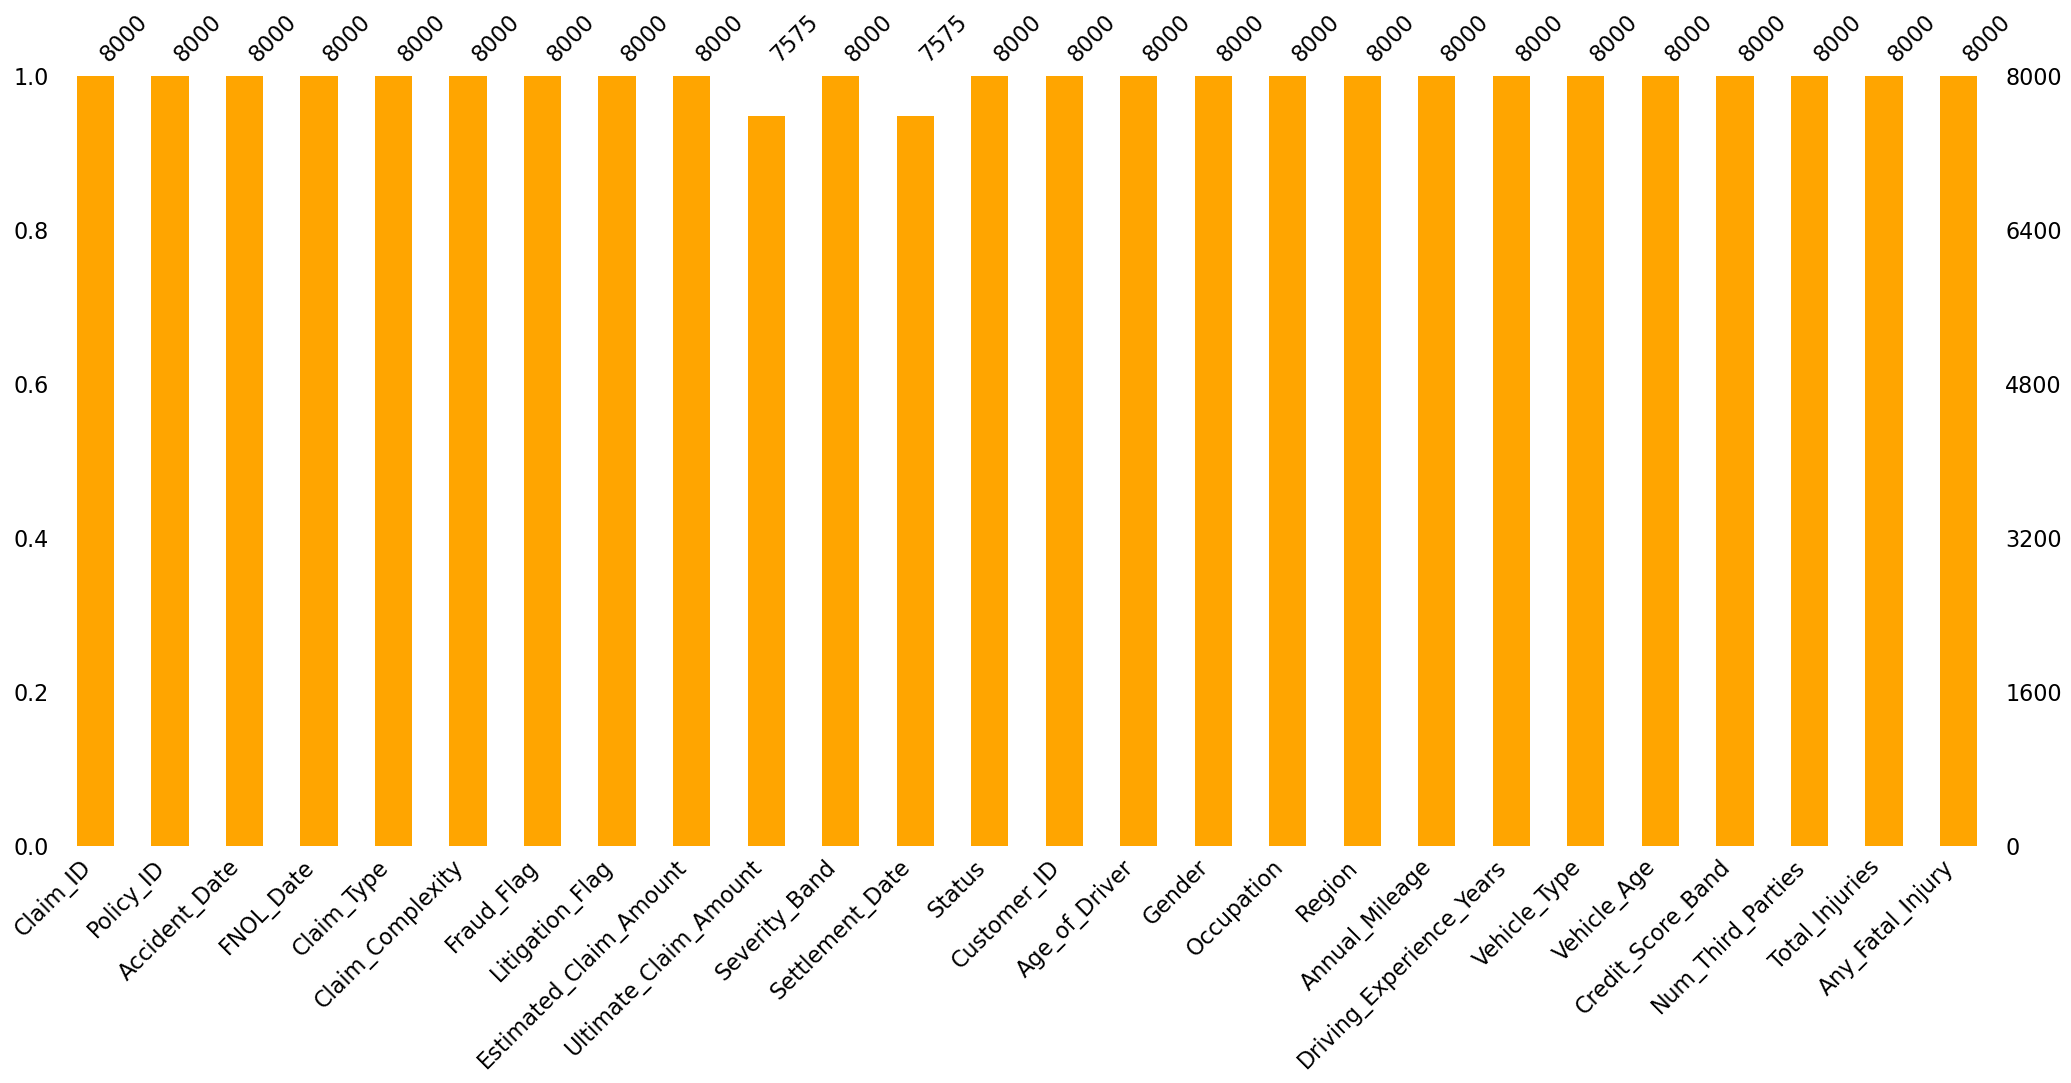

In [255]:
# Visualize missing values

msno.bar(final_dataset, color="orange");

In [256]:
# Drop missing data

final_dataset.dropna(inplace=True)


In [257]:
final_dataset.isnull().sum()

Claim_ID                    0
Policy_ID                   0
Accident_Date               0
FNOL_Date                   0
Claim_Type                  0
Claim_Complexity            0
Fraud_Flag                  0
Litigation_Flag             0
Estimated_Claim_Amount      0
Ultimate_Claim_Amount       0
Severity_Band               0
Settlement_Date             0
Status                      0
Customer_ID                 0
Age_of_Driver               0
Gender                      0
Occupation                  0
Region                      0
Annual_Mileage              0
Driving_Experience_Years    0
Vehicle_Type                0
Vehicle_Age                 0
Credit_Score_Band           0
Num_Third_Parties           0
Total_Injuries              0
Any_Fatal_Injury            0
dtype: int64

In [258]:
# Fix date datatype

final_dataset["Accident_Date"] = pd.to_datetime(final_dataset["Accident_Date"])
final_dataset["FNOL_Date"] = pd.to_datetime(final_dataset["FNOL_Date"])
final_dataset["Settlement_Date"] = pd.to_datetime(final_dataset["Settlement_Date"])

In [259]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7575 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Claim_ID                  7575 non-null   object        
 1   Policy_ID                 7575 non-null   object        
 2   Accident_Date             7575 non-null   datetime64[ns]
 3   FNOL_Date                 7575 non-null   datetime64[ns]
 4   Claim_Type                7575 non-null   object        
 5   Claim_Complexity          7575 non-null   object        
 6   Fraud_Flag                7575 non-null   bool          
 7   Litigation_Flag           7575 non-null   bool          
 8   Estimated_Claim_Amount    7575 non-null   int64         
 9   Ultimate_Claim_Amount     7575 non-null   float64       
 10  Severity_Band             7575 non-null   object        
 11  Settlement_Date           7575 non-null   datetime64[ns]
 12  Status                   

In [260]:
# Check for impossible values

final_dataset.loc[final_dataset["Age_of_Driver"] < 16]
final_dataset.loc[final_dataset["Vehicle_Age"] <0]

,Claim_ID,Policy_ID,Accident_Date,FNOL_Date,Claim_Type,Claim_Complexity,Fraud_Flag,Litigation_Flag,Estimated_Claim_Amount,Ultimate_Claim_Amount,...,Occupation,Region,Annual_Mileage,Driving_Experience_Years,Vehicle_Type,Vehicle_Age,Credit_Score_Band,Num_Third_Parties,Total_Injuries,Any_Fatal_Injury


## Feature Engineering

In [261]:
# Time-Based Feature 
# FNOL delay (time lapse between accident and reporting)
# Late reporting often signals complexity or fraud 


final_dataset["FNOL_Delay_Days"] = (
    final_dataset["FNOL_Date"] - 
    final_dataset["Accident_Date"]
).dt.days




In [262]:
final_dataset.head(2)

,Claim_ID,Policy_ID,Accident_Date,FNOL_Date,Claim_Type,Claim_Complexity,Fraud_Flag,Litigation_Flag,Estimated_Claim_Amount,Ultimate_Claim_Amount,...,Region,Annual_Mileage,Driving_Experience_Years,Vehicle_Type,Vehicle_Age,Credit_Score_Band,Num_Third_Parties,Total_Injuries,Any_Fatal_Injury,FNOL_Delay_Days
0,CLM30000,POL14506,2019-12-19,2019-12-19,Theft,Medium,False,True,5243,2808.0,...,Glasgow,4891,34,Hatchback,6,Excellent,1.0,1.0,0.0,0
1,CLM30001,POL14338,2018-12-30,2018-12-31,Collision,Low,False,False,3934,2952.0,...,Newcastle,18408,23,Van,9,Fair,0.0,0.0,0.0,1


In [263]:
# Time based features for accident date
# Captures seasonality effects by month and week behaviour

final_dataset["Accident_Month"] = (
    final_dataset["Accident_Date"].dt.month
)

final_dataset["Accident_day_of_week"] = (
    final_dataset["Accident_Date"].dt.dayofweek
)


In [264]:
final_dataset.head(2)

,Claim_ID,Policy_ID,Accident_Date,FNOL_Date,Claim_Type,Claim_Complexity,Fraud_Flag,Litigation_Flag,Estimated_Claim_Amount,Ultimate_Claim_Amount,...,Driving_Experience_Years,Vehicle_Type,Vehicle_Age,Credit_Score_Band,Num_Third_Parties,Total_Injuries,Any_Fatal_Injury,FNOL_Delay_Days,Accident_Month,Accident_day_of_week
0,CLM30000,POL14506,2019-12-19,2019-12-19,Theft,Medium,False,True,5243,2808.0,...,34,Hatchback,6,Excellent,1.0,1.0,0.0,0,12,3
1,CLM30001,POL14338,2018-12-30,2018-12-31,Collision,Low,False,False,3934,2952.0,...,23,Van,9,Fair,0.0,0.0,0.0,1,12,6


In [265]:
# Driver age 
# Approximates the age at which the driver started driving

# Age minus driving experience
final_dataset["Age_Minus_Experience"] = (
    final_dataset["Age_of_Driver"] - final_dataset["Driving_Experience_Years"]
)

### OUTLIERS

Check outliers in numeric columns

In [266]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7575 entries, 0 to 7999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Claim_ID                  7575 non-null   object        
 1   Policy_ID                 7575 non-null   object        
 2   Accident_Date             7575 non-null   datetime64[ns]
 3   FNOL_Date                 7575 non-null   datetime64[ns]
 4   Claim_Type                7575 non-null   object        
 5   Claim_Complexity          7575 non-null   object        
 6   Fraud_Flag                7575 non-null   bool          
 7   Litigation_Flag           7575 non-null   bool          
 8   Estimated_Claim_Amount    7575 non-null   int64         
 9   Ultimate_Claim_Amount     7575 non-null   float64       
 10  Severity_Band             7575 non-null   object        
 11  Settlement_Date           7575 non-null   datetime64[ns]
 12  Status                   

In [267]:
# Select Numeric Columns

numerical_columns = (
    final_dataset
    .select_dtypes(include="int")
    .drop(columns=["Estimated_Claim_Amount", "Accident_Month", "Accident_day_of_week"])
)


numerical_columns

,Age_of_Driver,Annual_Mileage,Driving_Experience_Years,Vehicle_Age,FNOL_Delay_Days,Age_Minus_Experience
0,53,4891,34,6,0,19
1,43,18408,23,9,1,20
2,19,10793,0,5,0,19
3,26,9405,5,13,0,21
4,27,16729,9,12,3,18
...,...,...,...,...,...,...
7995,38,11665,19,9,0,19
7996,58,17748,39,1,1,19
7997,32,19628,13,7,0,19
7998,40,15456,18,18,2,22


In [268]:
# Length of numerical columns in above dataframe

len(numerical_columns.columns)

6

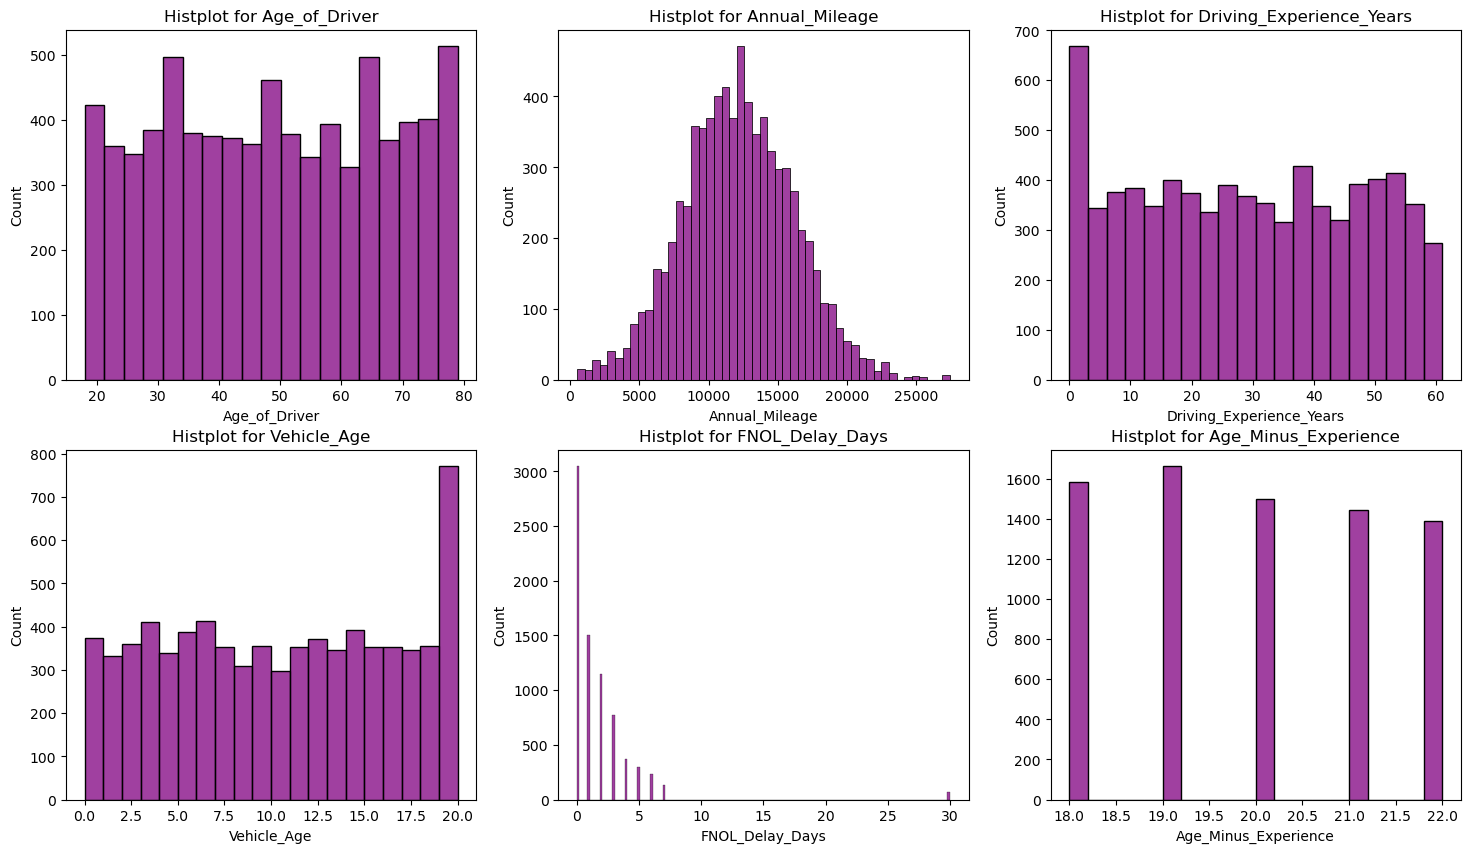

In [269]:
# Visualise skewness

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18,10))
ax = ax.flatten()

for idx, col in enumerate(numerical_columns):
    sns.histplot(final_dataset[col], ax=ax[idx], color="purple")
    ax[idx].set_title(f"Histplot for {col}")
plt.show()

1. Age_of_Driver: even spread from late teens to 80 years. no extreme spike or impossible values. These are real policyholders not data errors. This will be kept as is. 
   
2. Annual_Milage: Shows a rough bell curve. high milage drivers are real and the upper tail may be meaningful

3. Driving_Years_Experience: Drivers with low experience less than 5 years dominates. High experience is not outlier, just older drivers.

4. Vehicle_Age: Uniform spread with spike at higher values. 

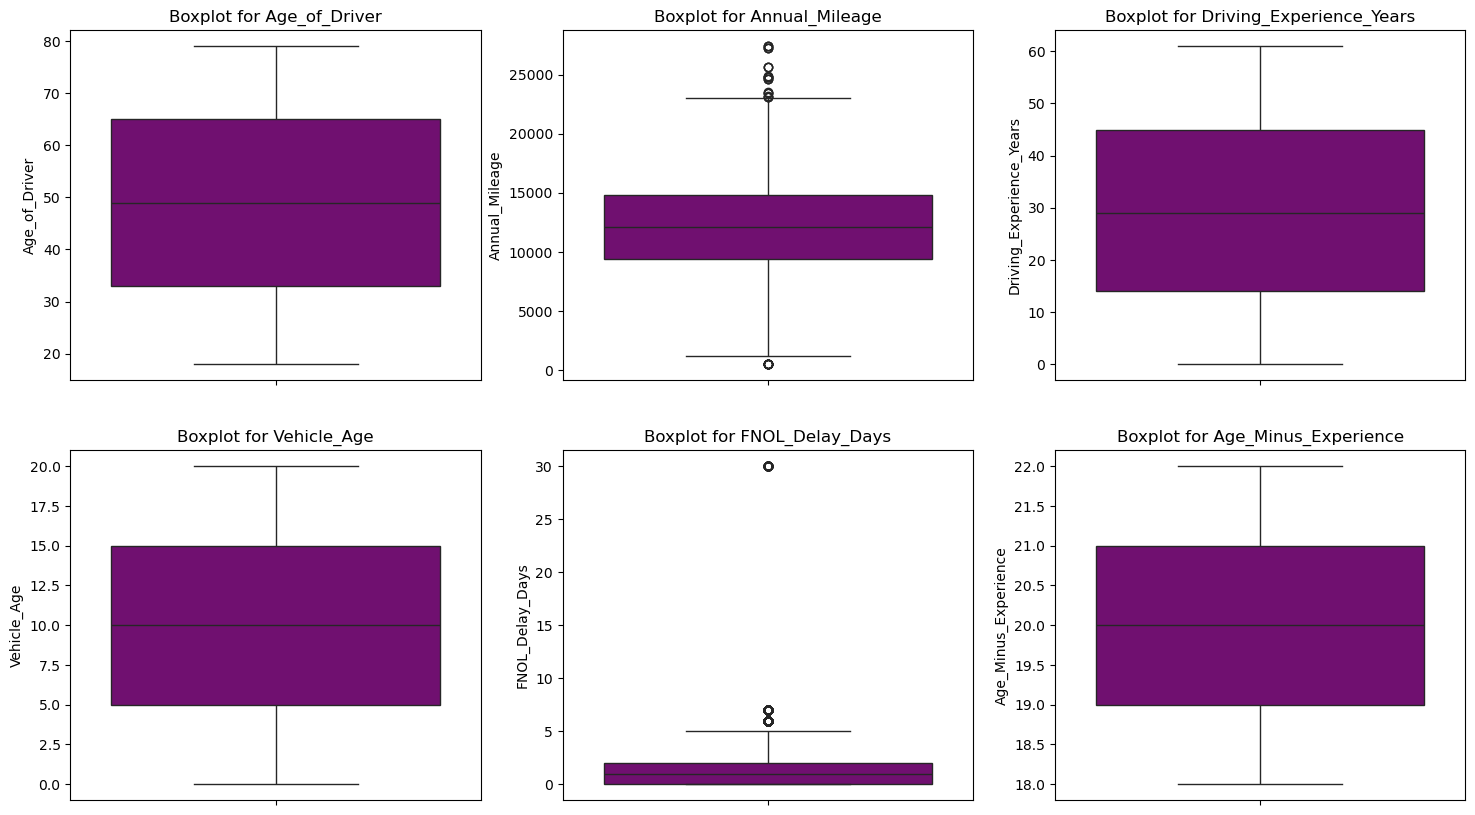

In [270]:
# Using boxplot to investigate the outliers further

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18,10))
ax = ax.flatten()

for idx, col in enumerate(numerical_columns):
    sns.boxplot(final_dataset[col], ax=ax[idx], color="purple")
    ax[idx].set_title(f"Boxplot for {col}")
plt.show()

1. Age_of _Driver: median is at middle age and no isolated points beyond whiskers. This means no outliers present.

2. Annual_Mileage: Outliers are seen above upper whiskers but lower bound is clean. High mileage signifies real exposure to risk. clip upperbound only.

3. Driving experience: No isolated extreme point so no outlier handling

4. Vehicle_age: No isolated extreme points. no cliping required.

5. FNOL_Delay_Days: Outliers present above whisker, pointing to late reporting. these may be a sign of litigation, fraud or dispute/escalation. 

### Handling the Outliers

In [271]:
# Handling outliers for Annual Mileage 


affected_column = ['Annual_Mileage']
q1 = final_dataset[affected_column].quantile(0.25)
q3 = final_dataset[affected_column].quantile(0.75)


In [272]:
iqr = q3 -q1

In [273]:
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

In [274]:
# Clipping outliers to upper and lower bound

final_dataset[affected_column] = final_dataset[affected_column].clip(lower=lower_bound, upper=upper_bound, axis=1)

In [275]:
# Handling outliers for FNOL_Delay_Days
# Using flags not clipping to preserve extreme delays which could be a strong risk signal

# creating a boolean column to flag claims reported more that 7 days after incident
final_dataset["Late_Notification_Flag"] = (
    final_dataset["FNOL_Delay_Days"] > 5
).astype(int)


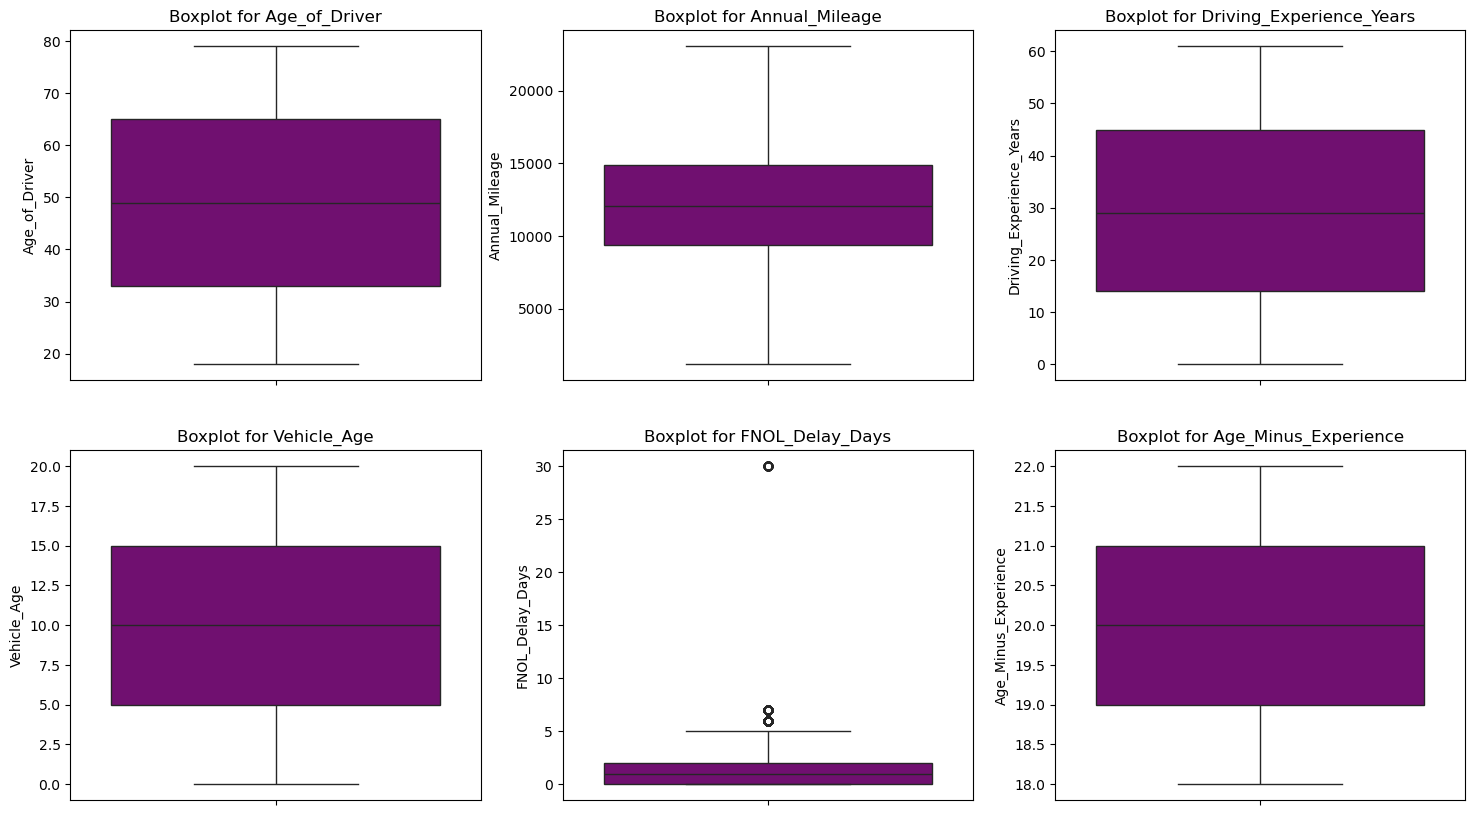

In [276]:
# Boxplot following handling of outliers

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18,10))
ax = ax.flatten()

for idx, col in enumerate(numerical_columns):
    sns.boxplot(final_dataset[col], ax=ax[idx], color="purple")
    ax[idx].set_title(f"Boxplot for {col}")
plt.show()

In [277]:
final_dataset.head(2)

,Claim_ID,Policy_ID,Accident_Date,FNOL_Date,Claim_Type,Claim_Complexity,Fraud_Flag,Litigation_Flag,Estimated_Claim_Amount,Ultimate_Claim_Amount,...,Vehicle_Age,Credit_Score_Band,Num_Third_Parties,Total_Injuries,Any_Fatal_Injury,FNOL_Delay_Days,Accident_Month,Accident_day_of_week,Age_Minus_Experience,Late_Notification_Flag
0,CLM30000,POL14506,2019-12-19,2019-12-19,Theft,Medium,False,True,5243,2808.0,...,6,Excellent,1.0,1.0,0.0,0,12,3,19,0
1,CLM30001,POL14338,2018-12-30,2018-12-31,Collision,Low,False,False,3934,2952.0,...,9,Fair,0.0,0.0,0.0,1,12,6,20,0


#### Inspecting Outlier for Ultimate Claim Amount (Target)

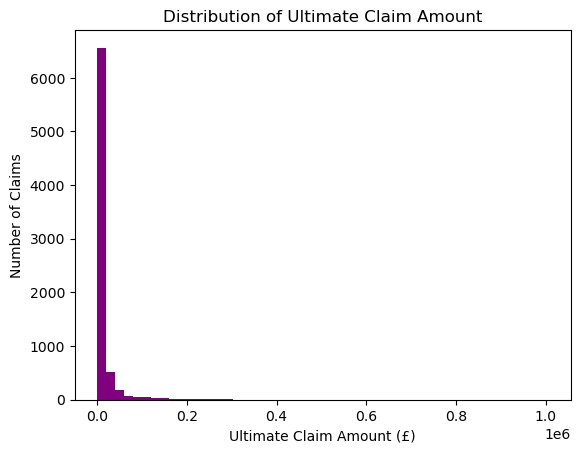

In [278]:
# Plot histogram of Ultimate Claim Amount
plt.figure()
plt.hist(
    final_dataset["Ultimate_Claim_Amount"],
    bins=50,
    color="purple"
)
plt.xlabel("Ultimate Claim Amount (£)")
plt.ylabel("Number of Claims")
plt.title("Distribution of Ultimate Claim Amount")
plt.show()


Heavily right skewed with a large number of small claims and long tail of very large claims.

Large amount of claims sit close to zero while only a small number of claims run into large amounts.  

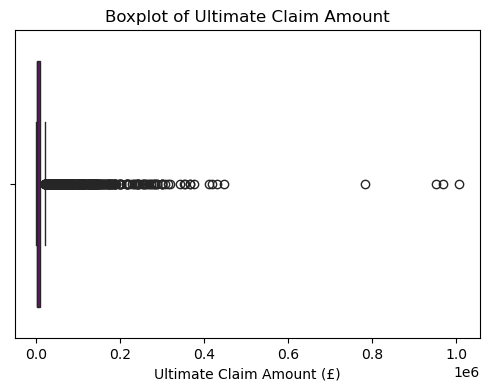

In [279]:
# Boxplot showing outliers

plt.figure(figsize=(6, 4))

sns.boxplot(
    x=final_dataset["Ultimate_Claim_Amount"],
    color="purple"
)

plt.title("Boxplot of Ultimate Claim Amount")
plt.xlabel("Ultimate Claim Amount (£)")

plt.show()


In [280]:
# Confirm skew and scale before transforming

final_dataset[
    ["Ultimate_Claim_Amount"]
].describe()

,Ultimate_Claim_Amount
count,7.575000e+03
mean,1.311868e+04
std,3.810405e+04
min,3.320000e+02
25%,1.578000e+03
50%,3.409000e+03
75%,9.744000e+03
max,1.005590e+06



count = 7,575 (Training population)
Min   = £332 (confirms low-severity claims in the data)
25% of claims cost less than £1,578 (the lower end is tightly clustered)
50% of claims cost less than £3,409 (this represents typical claim not mean)
75% of claims cost less than £9,744
This means that most claims are less than £10k. therefore, highcost claims are relatively rare

Mean = £13,119 (average claim much less than median)
a small number of very large claims are pulling the average up

Standard Deviation = £38,104
The spread is 3x the mean. this signals huge variability and presence of extreme values

Maximum £1,8005,590
There are claims over £1million. this is why the mean is inflated.
They should not be considered errors but real business losses

In insurance, most outliers are risk signal and must be carefully handled. In this case, Log Transformation will be used because it would help control the influence of outliers without eliminating them.  


In [281]:
# Apply log transformation 

final_dataset["log_Ultimate_Claim_Amount"] = np.log1p(
    final_dataset["Ultimate_Claim_Amount"]
)

In [282]:
# Verify Transformed Values

final_dataset[
    ["log_Ultimate_Claim_Amount"]
].describe()

# The mean and median are now closer together

,log_Ultimate_Claim_Amount
count,7575.000000
mean,8.383141
std,1.283887
min,5.808142
25%,7.364547
50%,8.134468
75%,9.184510
max,13.821086


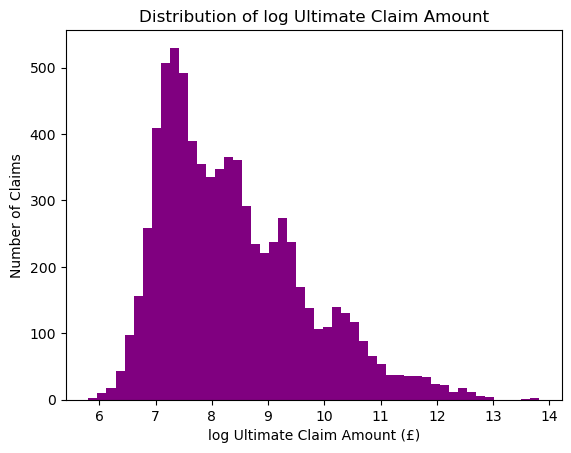

In [283]:
# Plot histogram of log_Ultimate_Claim_Amount

plt.figure()
plt.hist(
    final_dataset["log_Ultimate_Claim_Amount"],
    bins=50,
    color="purple"
)
plt.xlabel("log Ultimate Claim Amount (£)")
plt.ylabel("Number of Claims")
plt.title("Distribution of log Ultimate Claim Amount")
plt.show()


In [284]:
# Sanity check\

final_dataset["log_Ultimate_Claim_Amount"].isna().sum()

np.int64(0)

#### Data Tables and Initial Assessments

The datasets were contained in 3 csv file which were imported and inspected individualy to understand data types, number of columns, statistical distributions and missing values. 

The separate datasets were then aggregated and modelled into a schema to establish a single modelling unit. The thirdparty dataset was aggregated to match individual claim which is the decision unit. without aggreagtion, one claim would have multiple rows to represent the third parties, therby appearing multiple times. 

The modelling ensures the following:

1. aggregates one row per column and all relevant information were aligned to it
2. facilitates the building of a predictive model because without joining, prediction will not be coherent
3. exposes the full risk picture and real cost drivers available at the point of FNOL
4. supports operational use which makes it deployable in real systems

#### Missing Values

The dataset contained 425 missing values from the ultimate claim column and the settlement date column. this made up 5.3% of the dataset. This are not actual missing values. it only means no claims were made, and because it represents an almost negligible propotion of the dataset, the decision was to drop thr rows from the dataset.

#### Feature Engineering

Timing: Late reporting often signals injury escalation, higher severity or fraud
1. Days_to_FNOL
2. Accident_day_of _Week
3. Accident Month

Driver risk Profile: Age is meaningful when driving experience is accounted for.
1. Age_minus_experience (This accounts for the age at which the driver started driving.)

Using age alone will penalize young drivers without consedering their years of experience. 
late starters have less exposure to real-world driving situations

#### Outliers
Five numeric columns were inspected for outliers, out of which two columns had extrem values extending beyond the whiskers. 

The annual mileage outliers were handled by clipping to the upper bound of the interquartile range.

The outliers for FNOL_Delay_Days were not clipped rather boolean flags were used to preserve extreme delays which could be a strong risk signal


#### Ultimate Claim Amount
The Ultimate Caim Amount which is the target was inspected for outliers and from the histplot, we can see that it is heavily right skewed with large amount of small claims and long tail of very large claims.

Large amount of claims sit close to zero while only a small number of claims run into large amounts.  

to porperly manage the outliers and prevent overfitting, Log Transformation was used because it controlled the influence of outliers without eliminating them. In insurance, most outliers are risk signal and must be carefully handled. 




* Change fraud and litigation flag to binary

## Exploratory Data Analysis 

In [285]:
final_dataset.head(2)

,Claim_ID,Policy_ID,Accident_Date,FNOL_Date,Claim_Type,Claim_Complexity,Fraud_Flag,Litigation_Flag,Estimated_Claim_Amount,Ultimate_Claim_Amount,...,Credit_Score_Band,Num_Third_Parties,Total_Injuries,Any_Fatal_Injury,FNOL_Delay_Days,Accident_Month,Accident_day_of_week,Age_Minus_Experience,Late_Notification_Flag,log_Ultimate_Claim_Amount
0,CLM30000,POL14506,2019-12-19,2019-12-19,Theft,Medium,False,True,5243,2808.0,...,Excellent,1.0,1.0,0.0,0,12,3,19,0,7.940584
1,CLM30001,POL14338,2018-12-30,2018-12-31,Collision,Low,False,False,3934,2952.0,...,Fair,0.0,0.0,0.0,1,12,6,20,0,7.990577


In [286]:
final_dataset.columns

Index(['Claim_ID', 'Policy_ID', 'Accident_Date', 'FNOL_Date', 'Claim_Type',
       'Claim_Complexity', 'Fraud_Flag', 'Litigation_Flag',
       'Estimated_Claim_Amount', 'Ultimate_Claim_Amount', 'Severity_Band',
       'Settlement_Date', 'Status', 'Customer_ID', 'Age_of_Driver', 'Gender',
       'Occupation', 'Region', 'Annual_Mileage', 'Driving_Experience_Years',
       'Vehicle_Type', 'Vehicle_Age', 'Credit_Score_Band', 'Num_Third_Parties',
       'Total_Injuries', 'Any_Fatal_Injury', 'FNOL_Delay_Days',
       'Accident_Month', 'Accident_day_of_week', 'Age_Minus_Experience',
       'Late_Notification_Flag', 'log_Ultimate_Claim_Amount'],
      dtype='object')

In [287]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7575 entries, 0 to 7999
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Claim_ID                   7575 non-null   object        
 1   Policy_ID                  7575 non-null   object        
 2   Accident_Date              7575 non-null   datetime64[ns]
 3   FNOL_Date                  7575 non-null   datetime64[ns]
 4   Claim_Type                 7575 non-null   object        
 5   Claim_Complexity           7575 non-null   object        
 6   Fraud_Flag                 7575 non-null   bool          
 7   Litigation_Flag            7575 non-null   bool          
 8   Estimated_Claim_Amount     7575 non-null   int64         
 9   Ultimate_Claim_Amount      7575 non-null   float64       
 10  Severity_Band              7575 non-null   object        
 11  Settlement_Date            7575 non-null   datetime64[ns]
 12  Status     

### Univariate Analysis for Numerical Columns

In [288]:
# Numerical column visualisation for integers

numerical_columns2 = (
    final_dataset
    .select_dtypes(include="int",)
    .drop(columns=["Estimated_Claim_Amount"])
)


numerical_columns2

,Age_of_Driver,Driving_Experience_Years,Vehicle_Age,FNOL_Delay_Days,Accident_Month,Accident_day_of_week,Age_Minus_Experience,Late_Notification_Flag
0,53,34,6,0,12,3,19,0
1,43,23,9,1,12,6,20,0
2,19,0,5,0,10,1,19,0
3,26,5,13,0,6,4,21,0
4,27,9,12,3,3,6,18,0
...,...,...,...,...,...,...,...,...
7995,38,19,9,0,5,3,19,0
7996,58,39,1,1,7,2,19,0
7997,32,13,7,0,11,4,19,0
7998,40,18,18,2,1,2,22,0


In [289]:
# Length of Column

len(numerical_columns2.columns)

8

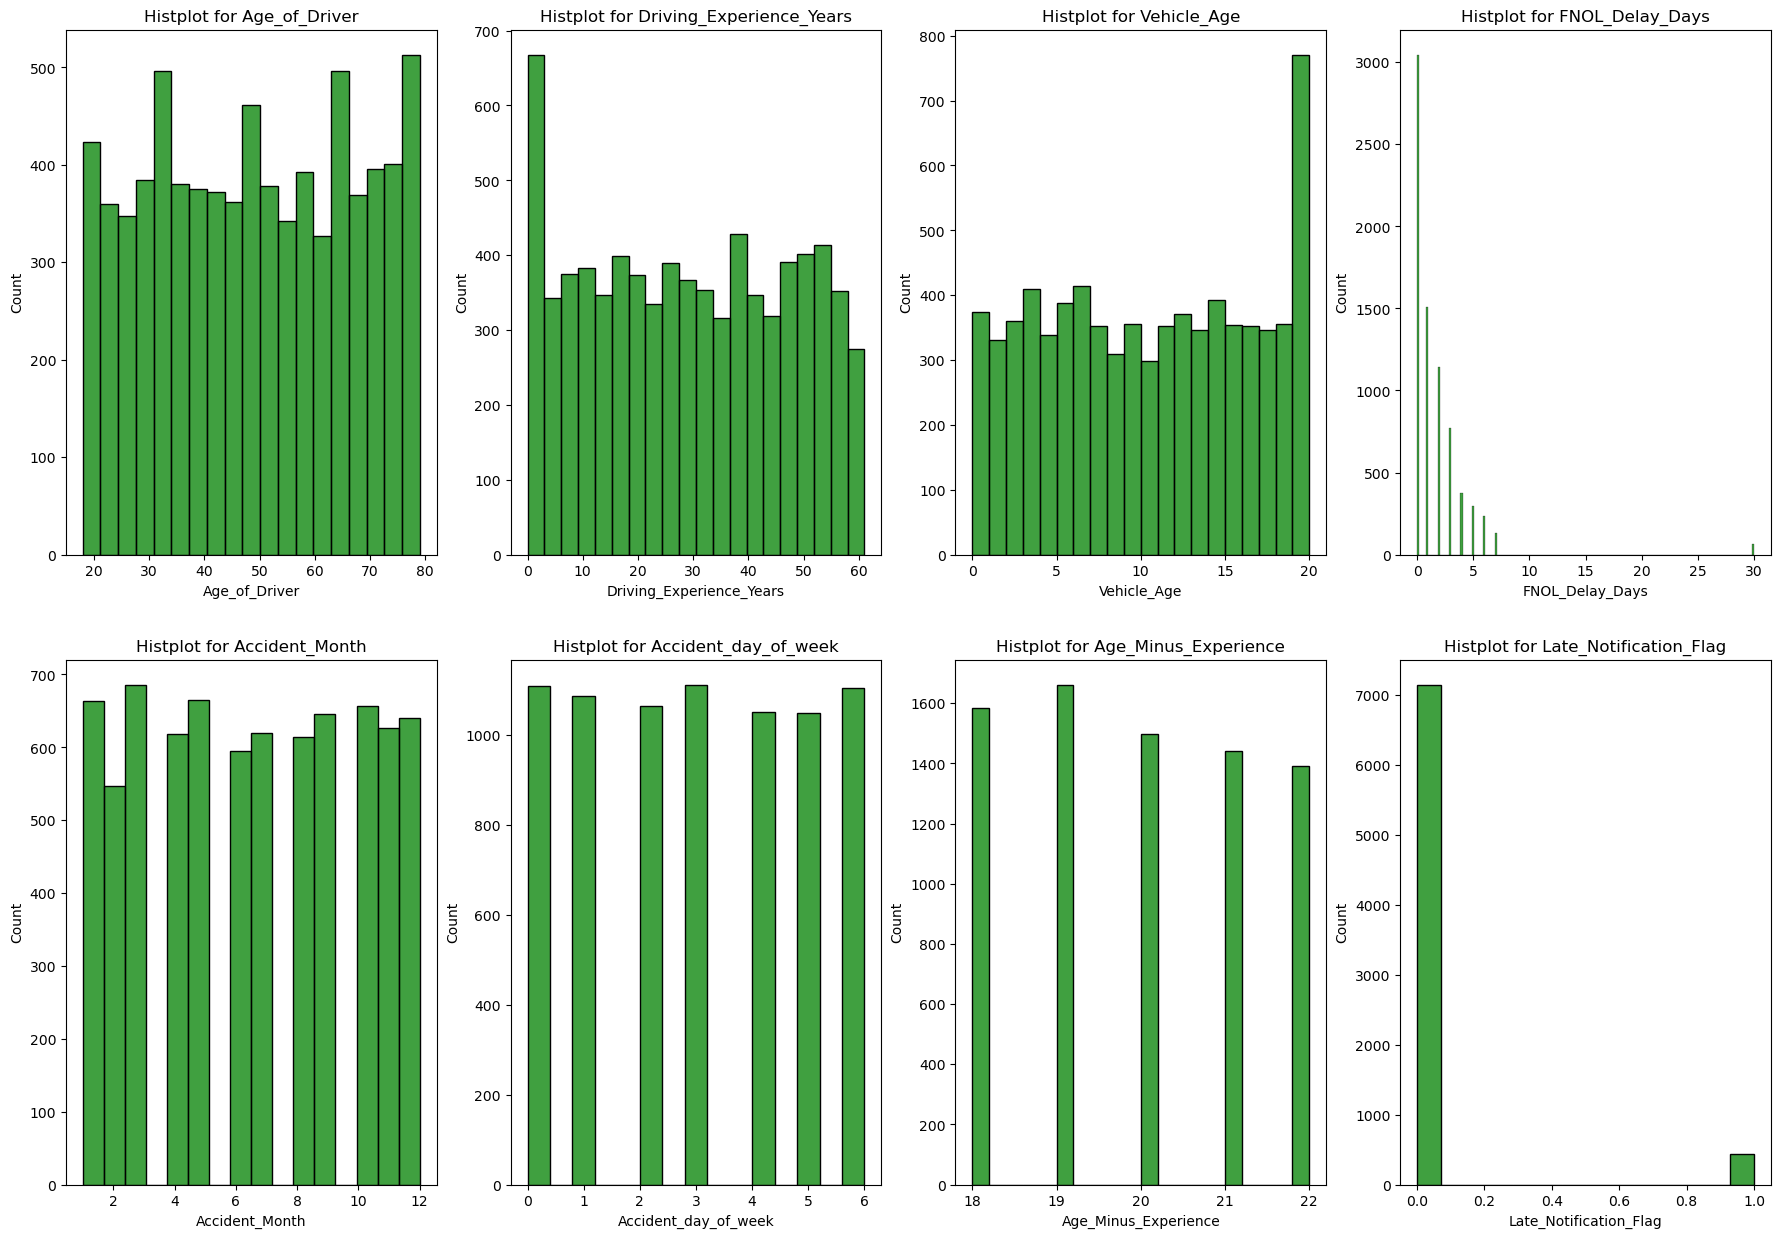

In [290]:

fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(22,15))
ax = ax.flatten()

for idx, col in enumerate(numerical_columns2):
    sns.histplot(final_dataset[col], ax=ax[idx], color="green")
    ax[idx].set_title(f"Histplot for {col}")
plt.show()

### Univariate Analysis for Categorical Columns

In [291]:
# Categorical column visualisation for integers

categorical_columns = (
    final_dataset
    .select_dtypes(include="object",)
    .drop(columns=["Claim_ID", "Policy_ID", "Customer_ID", "Occupation", "Gender", "Region", "Status", "Credit_Score_Band"])
)


categorical_columns

,Claim_Type,Claim_Complexity,Severity_Band,Vehicle_Type
0,Theft,Medium,Minor,Hatchback
1,Collision,Low,Minor,Van
2,Other,Medium,Catastrophic,SUV
3,Weather,Low,Minor,Hatchback
4,Theft,Low,Minor,Hatchback
...,...,...,...,...
7995,Fire,Low,Major,SUV
7996,Collision,Low,Minor,SUV
7997,Theft,Low,Minor,Hatchback
7998,Fire,Medium,Moderate,SUV


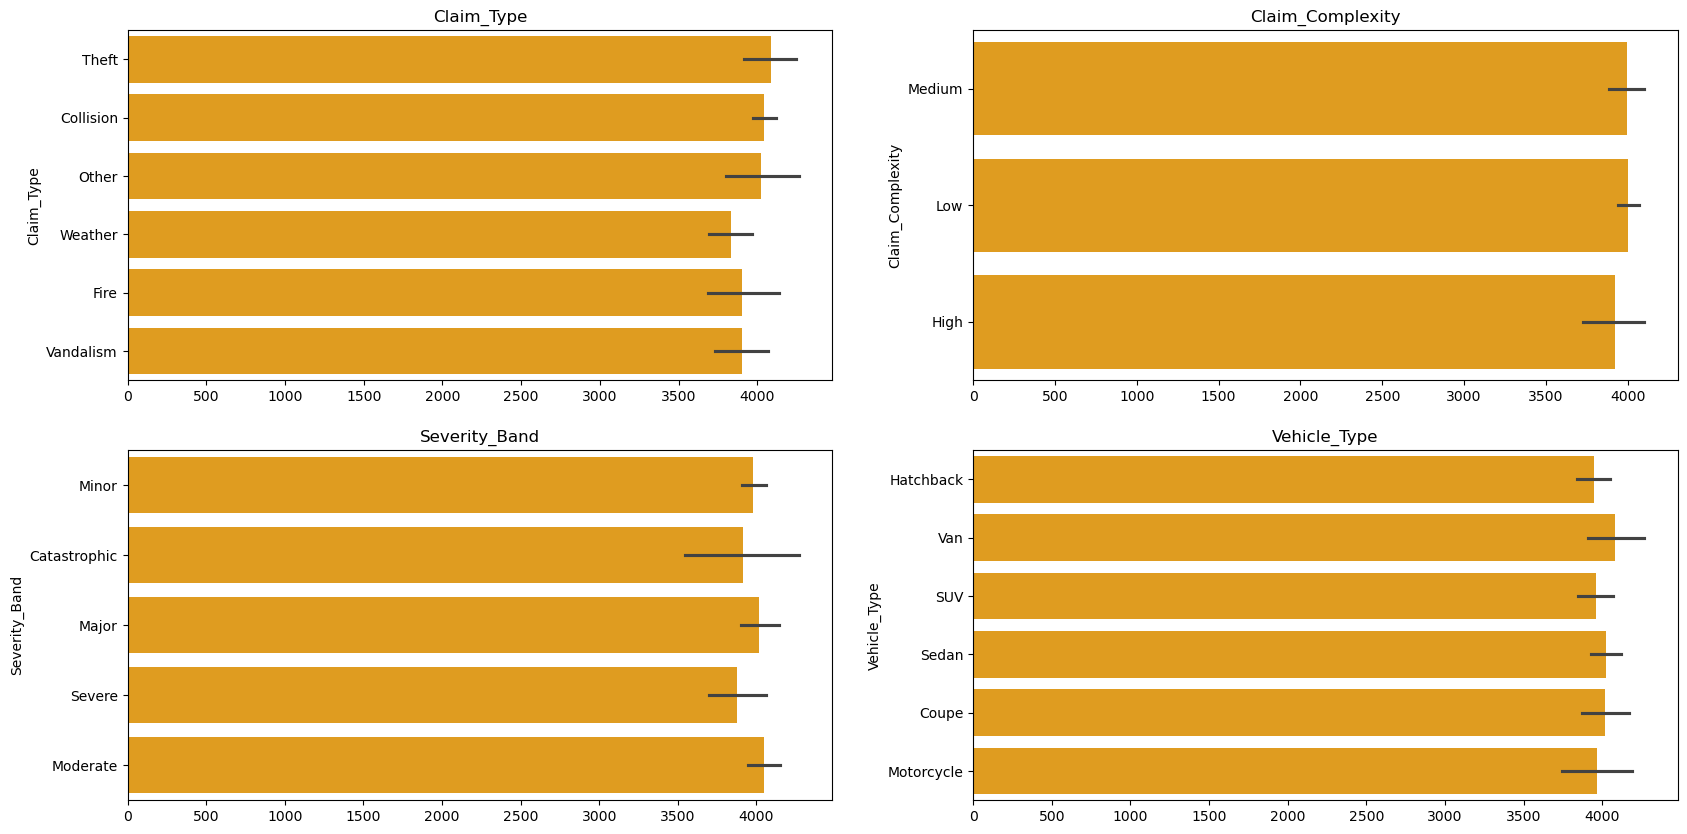

In [292]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20,10))
ax = ax.flatten()

for idx, col in enumerate(categorical_columns):
    sns.barplot(final_dataset[col], ax=ax[idx], color="orange")
    ax[idx].set_title(f"{col}")
plt.show()

In [293]:
final_dataset.head(2)

,Claim_ID,Policy_ID,Accident_Date,FNOL_Date,Claim_Type,Claim_Complexity,Fraud_Flag,Litigation_Flag,Estimated_Claim_Amount,Ultimate_Claim_Amount,...,Credit_Score_Band,Num_Third_Parties,Total_Injuries,Any_Fatal_Injury,FNOL_Delay_Days,Accident_Month,Accident_day_of_week,Age_Minus_Experience,Late_Notification_Flag,log_Ultimate_Claim_Amount
0,CLM30000,POL14506,2019-12-19,2019-12-19,Theft,Medium,False,True,5243,2808.0,...,Excellent,1.0,1.0,0.0,0,12,3,19,0,7.940584
1,CLM30001,POL14338,2018-12-30,2018-12-31,Collision,Low,False,False,3934,2952.0,...,Fair,0.0,0.0,0.0,1,12,6,20,0,7.990577


In [294]:
final_dataset.columns

Index(['Claim_ID', 'Policy_ID', 'Accident_Date', 'FNOL_Date', 'Claim_Type',
       'Claim_Complexity', 'Fraud_Flag', 'Litigation_Flag',
       'Estimated_Claim_Amount', 'Ultimate_Claim_Amount', 'Severity_Band',
       'Settlement_Date', 'Status', 'Customer_ID', 'Age_of_Driver', 'Gender',
       'Occupation', 'Region', 'Annual_Mileage', 'Driving_Experience_Years',
       'Vehicle_Type', 'Vehicle_Age', 'Credit_Score_Band', 'Num_Third_Parties',
       'Total_Injuries', 'Any_Fatal_Injury', 'FNOL_Delay_Days',
       'Accident_Month', 'Accident_day_of_week', 'Age_Minus_Experience',
       'Late_Notification_Flag', 'log_Ultimate_Claim_Amount'],
      dtype='object')

### Bivariate Analysis

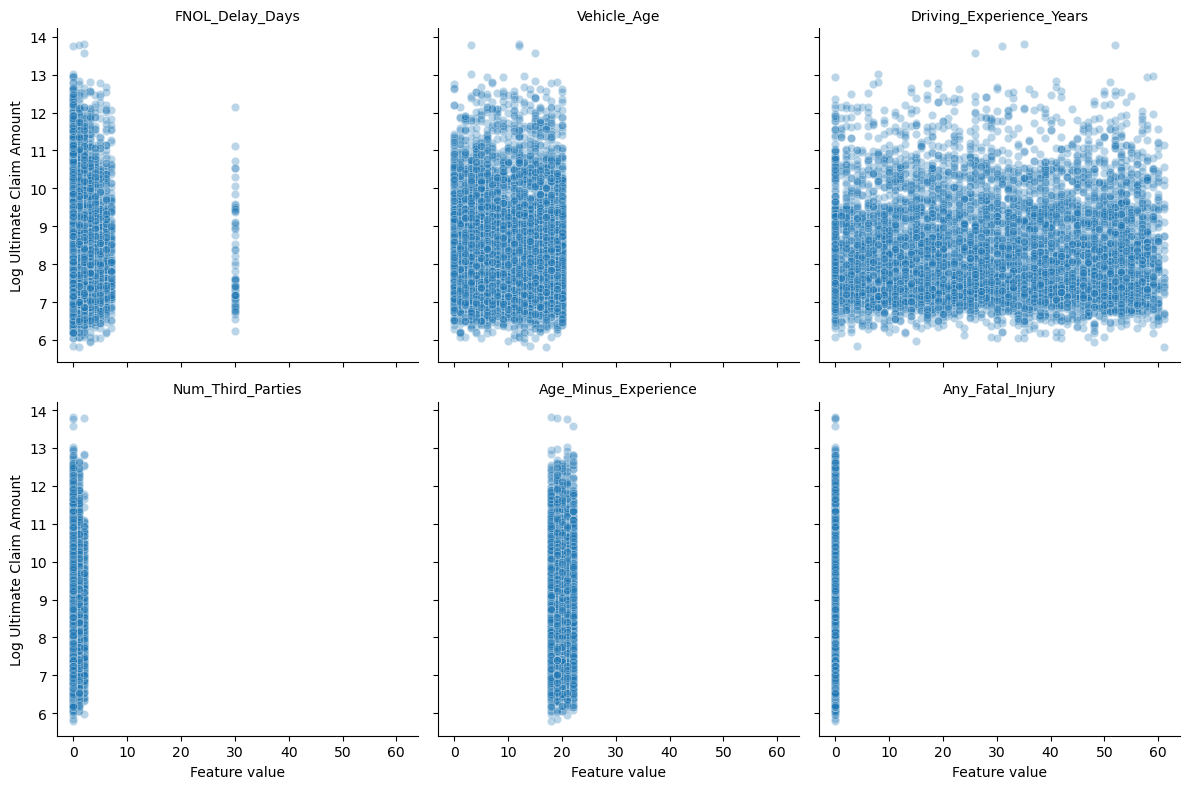

In [295]:
# Numerical Variables vs log ultimate claim amount
# Variables to plot
plot_cols = [
    "FNOL_Delay_Days",
    "Vehicle_Age",
    "Driving_Experience_Years",
    "Num_Third_Parties",
    "Age_Minus_Experience",
    "Any_Fatal_Injury"
]

# Prepare data
plot_df = final_dataset[
    plot_cols + ["log_Ultimate_Claim_Amount"]
].copy()

# Reshape for faceting
plot_df_long = plot_df.melt(
    id_vars="log_Ultimate_Claim_Amount",
    value_vars=plot_cols,
    var_name="Feature",
    value_name="Value"
)

# Faceted scatter plot
g = sns.FacetGrid(
    plot_df_long,
    col="Feature",
    col_wrap=3,
    height=4,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="Value",
    y="log_Ultimate_Claim_Amount",
    alpha=0.3
)

g.set_axis_labels("Feature value", "Log Ultimate Claim Amount")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()


Many repeated values on the x axis explains the blocked or striped nature of the scatterplots. this also means that the relationship is not linear. eg. for FNOL delay, 0, 1, 2 days are very common. 

Main Question: Does the variable increase the chance of higher claim?

FNOL_Delay: Most dots are at low delay, meaning people report quickly. as delay increases, dots spread higher. Late reporting dosent gurantee a big claim but it increases the chance.

Vehicle Age: No clear slope as dots are spread evenly. Vehicle age alone does not change how expensive a  claim becomes. 

Driving experience: slightly more dots on the left where there is less driving experience. Less experience may result in slightly more claims.

Number of third Parties: Where third parties are involved, the claims starts from higher amount. more people = more money involved.

Age_Minus_Experience: The age at which the driver started driving. Many drivers started around similar ages. As age increased, slightly higher severity claims appear. Late starters may not have big claims but when things go wrong, they tend to go more wrong as a result of less accumulated driving intuition.

Any_Fatal_Injury: This is represented by binary flag. 

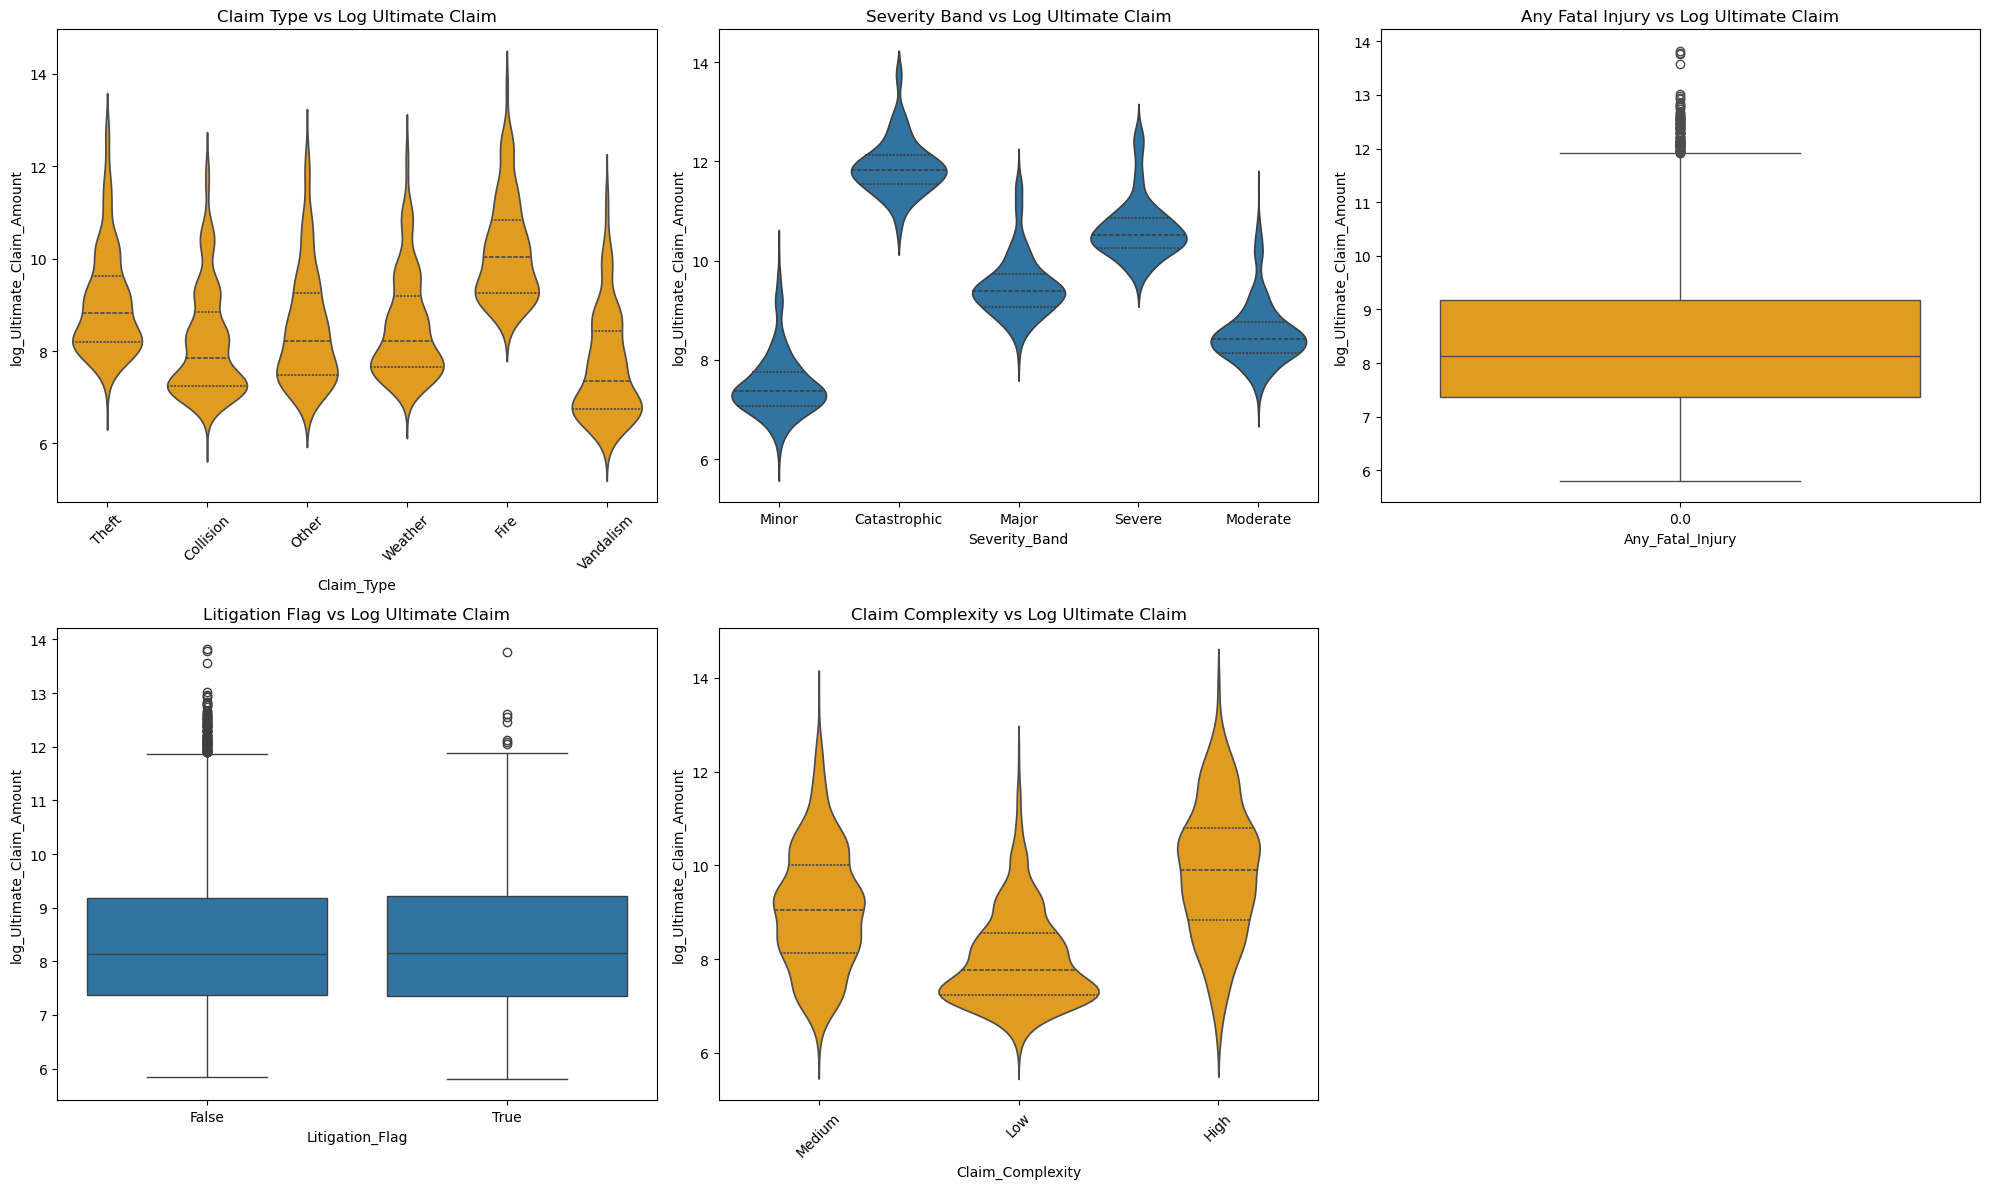

In [296]:
# Categorical Variables vs log ultimate claim amount

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

sns.violinplot(
    data=final_dataset,
    x="Claim_Type",
    y="log_Ultimate_Claim_Amount",
    ax=axes[0],
    color="orange",
    inner="quartile"
)
axes[0].set_title("Claim Type vs Log Ultimate Claim")
axes[0].tick_params(axis="x", rotation=45)

sns.violinplot(
    data=final_dataset,
    x="Severity_Band",
    y="log_Ultimate_Claim_Amount",
    ax=axes[1],
    inner="quartile"
)
axes[1].set_title("Severity Band vs Log Ultimate Claim")

sns.boxplot(
    data=final_dataset,
    x="Any_Fatal_Injury",
    y="log_Ultimate_Claim_Amount",
    color="orange",
    ax=axes[2]
)
axes[2].set_title("Any Fatal Injury vs Log Ultimate Claim")

sns.boxplot(
    data=final_dataset,
    x="Litigation_Flag",
    y="log_Ultimate_Claim_Amount",
    ax=axes[3]
)
axes[3].set_title("Litigation Flag vs Log Ultimate Claim")

sns.violinplot(
    data=final_dataset,
    x="Claim_Complexity",
    y="log_Ultimate_Claim_Amount",
    ax=axes[4],
    color="orange",
    inner="quartile"
)
axes[4].set_title("Claim Complexity vs Log Ultimate Claim")
axes[4].tick_params(axis="x", rotation=45)

axes[5].axis("off")

plt.tight_layout()
plt.show()


This shows the median, quantiles and where most claims actually sit. 

Claim_Type Vs Log_Ultimate Claim: Claim Type is a structural severity drivers. the narrow and low shapes have cheaper and more predictable claims while the wider shapes with long tails are more expensive and risky. 
fire and Weather claims have higher costs and much thicker upper tails. 

Severity Band: Shows very clean upward progression and correctly captures increasing injury or damage seriousness. 

Claim Complexity: Clear separation between low, medium and high complexity

In [297]:
# Multivariate Analysis

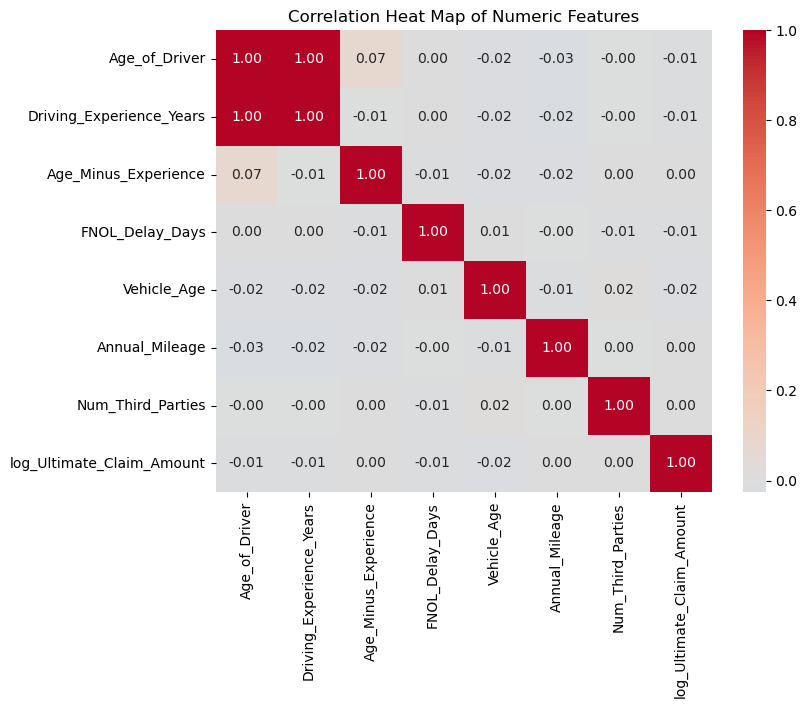

In [298]:
numeric_features = [
    "Age_of_Driver",
    "Driving_Experience_Years",
    "Age_Minus_Experience",
    "FNOL_Delay_Days",
    "Vehicle_Age",
    "Annual_Mileage",
    "Num_Third_Parties",
    "log_Ultimate_Claim_Amount"
]

corr_matrix = final_dataset[numeric_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heat Map of Numeric Features")
plt.show()


Correlation heatmap was used to screen for multicollinearity among numeric variables. 

Age_of_driver and driving_Experience_Years are almost perfectly correlated which means strong multicollinearity.

Age_Minus_Experience behaves differently because it captures new information than raw age.

FNOL_Days, Num_Third_Parties, Vehicle_Age all show near zero correlation, meaning that they operate independently, giving a non-linear effect

Annual Mileage also shows a near-zero correlation. 

In summary, the heatmap shows strong multicollinearity between age and driving experience, while most other predictors exhibit weak linear correlation.

### Statistical Ananlysis to Further explore Multicollinearity

Variance Inflation Factor (VIF) : This tells if a variable is redundant compared to others by quantifying how much information overlaps.

VIF = 1 no redundancy
VIF > 5 concerning
VIF > 10 severe multicollinearity

In [299]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7575 entries, 0 to 7999
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Claim_ID                   7575 non-null   object        
 1   Policy_ID                  7575 non-null   object        
 2   Accident_Date              7575 non-null   datetime64[ns]
 3   FNOL_Date                  7575 non-null   datetime64[ns]
 4   Claim_Type                 7575 non-null   object        
 5   Claim_Complexity           7575 non-null   object        
 6   Fraud_Flag                 7575 non-null   bool          
 7   Litigation_Flag            7575 non-null   bool          
 8   Estimated_Claim_Amount     7575 non-null   int64         
 9   Ultimate_Claim_Amount      7575 non-null   float64       
 10  Severity_Band              7575 non-null   object        
 11  Settlement_Date            7575 non-null   datetime64[ns]
 12  Status     

In [300]:
# Accessing numerical features for multicolliniarity using the Variance Inflation Factor (VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_vars = [
    "Age_of_Driver",
    "Driving_Experience_Years",
    "Age_Minus_Experience",
    "FNOL_Delay_Days",
    "Vehicle_Age",
    "Annual_Mileage",
    "Num_Third_Parties",
    "Total_Injuries",
    "Accident_Month", 
    "Accident_day_of_week"
    
    
]

X = final_dataset[numeric_vars].dropna()

vif_df = pd.DataFrame()
vif_df["Feature"] = X.columns
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_df

C:\Users\Lilian Ofuonye\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,Age_of_Driver,inf
1,Driving_Experience_Years,inf
2,Age_Minus_Experience,inf
3,FNOL_Delay_Days,1.307862
4,Vehicle_Age,3.617402
5,Annual_Mileage,9.700444
6,Num_Third_Parties,inf
7,Total_Injuries,inf
8,Accident_Month,4.482939
9,Accident_day_of_week,3.185594


Variance Inflation Factor (VIF) analysis identified perfect multicollinearity between age, driving experience, and the derived age-minus-experience feature. One representative variable will be retained. 

In [301]:
final_dataset.columns

Index(['Claim_ID', 'Policy_ID', 'Accident_Date', 'FNOL_Date', 'Claim_Type',
       'Claim_Complexity', 'Fraud_Flag', 'Litigation_Flag',
       'Estimated_Claim_Amount', 'Ultimate_Claim_Amount', 'Severity_Band',
       'Settlement_Date', 'Status', 'Customer_ID', 'Age_of_Driver', 'Gender',
       'Occupation', 'Region', 'Annual_Mileage', 'Driving_Experience_Years',
       'Vehicle_Type', 'Vehicle_Age', 'Credit_Score_Band', 'Num_Third_Parties',
       'Total_Injuries', 'Any_Fatal_Injury', 'FNOL_Delay_Days',
       'Accident_Month', 'Accident_day_of_week', 'Age_Minus_Experience',
       'Late_Notification_Flag', 'log_Ultimate_Claim_Amount'],
      dtype='object')

### Features to be dropped

1. Claim_ID: basic identifier. no predictive relevance
2. Policy_ID: basic identifier. no predictive relevance
3. Customer_ID: basic identifier. no predictive relevance
4. Settlement_Date: This feature is not known at FNOL (Outcome related). Only features known at FNOL sould be included
5. Status: Outcome related
6. Age_of_Driver: multicolliniarity in age related features. 
7. Age_Minus_Experience: multicolliniarity in age related features.
8. Accident_Date: FNOL_Delay_Days already extracted and this will introduce noise.
9. FNOL_Date: FNOL_Delay_Days already extracted and this will introduce noise.
10. Num_Third_Parties: ultimate cost claim is driven by injured people not number of thirdparties. it dosent explain severity as much as total_injuries.
11. log_Ultimate_claim_amount: Model will be trained on the log scale and predictions exponentiated back to original state. 

In [302]:
# Define columns to be dropped

columns_to_drop = [
    "Claim_ID",
    "Policy_ID",
    "Customer_ID",
    "Settlement_Date",
    "Age_of_Driver",
    "Age_Minus_Experience",
    "Accident_Date",
    "FNOL_Date",
    "Status",
    "Num_Third_Parties",
    "log_Ultimate_Claim_Amount"
]

In [303]:
# Drop columns that actually exist

cols_existing = [c for c in columns_to_drop if c in final_dataset.columns]

model_dataset = final_dataset.drop(columns=cols_existing)


In [304]:
model_dataset.columns

Index(['Claim_Type', 'Claim_Complexity', 'Fraud_Flag', 'Litigation_Flag',
       'Estimated_Claim_Amount', 'Ultimate_Claim_Amount', 'Severity_Band',
       'Gender', 'Occupation', 'Region', 'Annual_Mileage',
       'Driving_Experience_Years', 'Vehicle_Type', 'Vehicle_Age',
       'Credit_Score_Band', 'Total_Injuries', 'Any_Fatal_Injury',
       'FNOL_Delay_Days', 'Accident_Month', 'Accident_day_of_week',
       'Late_Notification_Flag'],
      dtype='object')

In [305]:
model_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7575 entries, 0 to 7999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Claim_Type                7575 non-null   object 
 1   Claim_Complexity          7575 non-null   object 
 2   Fraud_Flag                7575 non-null   bool   
 3   Litigation_Flag           7575 non-null   bool   
 4   Estimated_Claim_Amount    7575 non-null   int64  
 5   Ultimate_Claim_Amount     7575 non-null   float64
 6   Severity_Band             7575 non-null   object 
 7   Gender                    7575 non-null   object 
 8   Occupation                7575 non-null   object 
 9   Region                    7575 non-null   object 
 10  Annual_Mileage            7575 non-null   float64
 11  Driving_Experience_Years  7575 non-null   int64  
 12  Vehicle_Type              7575 non-null   object 
 13  Vehicle_Age               7575 non-null   int64  
 14  Credit_Score_

### Encoding Categorical Variables

1. Ordinal encoding for Claim_ Complexity, Credit_Score_Band and Severity_Band
2. One-hot encoding for Claim_Type, Gender, Occupation, Religion, Vehicle_Type

In [306]:
# Ordinal Encoding

ordinal_mappings = {
    "Claim_Complexity": {
        "Low": 1,
        "Medium": 2,
        "High": 3
    },
    "Severity_Band": {
        "Minor": 1,
        "Moderate": 2,
        "Major": 3,
        "Severe": 4,
        "Catastrophic": 5
    },
    "Credit_Score_Band": {
        "Poor": 1,
        "Good": 2,
        "Fair": 3,
        "Excellent": 4
    }
}

for col, mapping in ordinal_mappings.items():
    model_dataset[col] = model_dataset[col].map(mapping)


In [307]:
model_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7575 entries, 0 to 7999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Claim_Type                7575 non-null   object 
 1   Claim_Complexity          7575 non-null   int64  
 2   Fraud_Flag                7575 non-null   bool   
 3   Litigation_Flag           7575 non-null   bool   
 4   Estimated_Claim_Amount    7575 non-null   int64  
 5   Ultimate_Claim_Amount     7575 non-null   float64
 6   Severity_Band             7575 non-null   int64  
 7   Gender                    7575 non-null   object 
 8   Occupation                7575 non-null   object 
 9   Region                    7575 non-null   object 
 10  Annual_Mileage            7575 non-null   float64
 11  Driving_Experience_Years  7575 non-null   int64  
 12  Vehicle_Type              7575 non-null   object 
 13  Vehicle_Age               7575 non-null   int64  
 14  Credit_Score_

In [308]:
# One-hot encoding
nominal_cols = [
    "Claim_Type",
    "Gender",
    "Occupation",
    "Region",
    "Vehicle_Type"
]

model_dataset = pd.get_dummies(
    model_dataset,
    columns=nominal_cols,
    drop_first=True
)



In [309]:
model_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7575 entries, 0 to 7999
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Claim_Complexity          7575 non-null   int64  
 1   Fraud_Flag                7575 non-null   bool   
 2   Litigation_Flag           7575 non-null   bool   
 3   Estimated_Claim_Amount    7575 non-null   int64  
 4   Ultimate_Claim_Amount     7575 non-null   float64
 5   Severity_Band             7575 non-null   int64  
 6   Annual_Mileage            7575 non-null   float64
 7   Driving_Experience_Years  7575 non-null   int64  
 8   Vehicle_Age               7575 non-null   int64  
 9   Credit_Score_Band         7575 non-null   int64  
 10  Total_Injuries            7575 non-null   float64
 11  Any_Fatal_Injury          7575 non-null   float64
 12  FNOL_Delay_Days           7575 non-null   int64  
 13  Accident_Month            7575 non-null   int32  
 14  Accident_day_

One-hot encoding introduces binary flags where one column represents one category, hence the additional columns.

#### Scaling Numerical Variables

In [310]:
columns_to_scale = [
    "FNOL_Delay_Days", 
    "Annual_Mileage", 
    "Vehicle_Age", 
    "Driving_Experience_Years", 
    "Total_Injuries"
]

In [311]:
from sklearn.preprocessing import StandardScaler

In [312]:
scaler = StandardScaler()

In [313]:
model_dataset[columns_to_scale] = scaler.fit_transform(
    model_dataset[columns_to_scale]
)


Continuous numeric features were standardised using a StandardScaler to bring them to a similar range with the aim of improving model performance. Standard scaler was used because it enables proper regularisation for linear models.


#### Feature Audit Before Modelling 

In [314]:
model_dataset.shape

(7575, 40)

In [315]:
model_dataset.dtypes.value_counts()

bool       26
float64     7
int64       5
int32       2
Name: count, dtype: int64

In [316]:
model_dataset.head(2)

,Claim_Complexity,Fraud_Flag,Litigation_Flag,Estimated_Claim_Amount,Ultimate_Claim_Amount,Severity_Band,Annual_Mileage,Driving_Experience_Years,Vehicle_Age,Credit_Score_Band,...,Region_Leeds,Region_Liverpool,Region_London,Region_Manchester,Region_Newcastle,Vehicle_Type_Hatchback,Vehicle_Type_Motorcycle,Vehicle_Type_SUV,Vehicle_Type_Sedan,Vehicle_Type_Van
0,2,False,True,5243,2808.0,1,-1.807408,0.274811,-0.655823,4,...,False,False,False,False,False,True,False,False,False,False
1,1,False,False,3934,2952.0,1,1.573879,-0.341323,-0.165332,3,...,False,False,False,False,True,False,False,False,False,True


## Pipeline and Baseline Model

In [317]:
# Freezing the final feature matrix

X = model_dataset.drop(columns=["Ultimate_Claim_Amount"])
X.dtypes.value_counts()


bool       26
float64     6
int64       5
int32       2
Name: count, dtype: int64

The target variable was removed from the feature set to prevent data leakage, and data types were inspected to ensure all predictors were in a numeric format suitable for modelling.

In [318]:
# Log transformed target variable

import numpy as np

y = np.log1p(model_dataset["Ultimate_Claim_Amount"])

The ultimate claim amount was log-transformed using log1p to handle zero values, reduce skewness, and stabilise variance prior to modelling. With this, there is no permanent change on the data and makes it easier to model. 

Now we have:

x = features
y = target 

This is what the model understands

#### Test - Train Split

In [319]:
# Splitting data into test and train datasets before modeling
# Data is split 20% for testing and 80% for training
# This separates learning from evaluation

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


The dataset was split into training and testing subsets to ensure the model was trained on one portion of the data and evaluated on unseen observations, providing an unbiased assessment of performance

#### Baseline Regression Model

1. This sets the minimum standard the model must beat and prevents false confidence.
2. It predicts the mean which is the minimum performance benchmark. if the model can not beat this, then its not useful. 


In [320]:

# Simple model provided by Scikit-learn
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline  

# Pipeline helps to group multiple steps into one object. 
# it keeps workflow consistent and avoids rewriting codes
# DummyRegressor can be replaced with linear regressor

baseline_pipe = Pipeline(
    steps=[
        ("model", DummyRegressor(strategy="mean"))
    ]
)

baseline_pipe.fit(X_train, y_train)

# calculates the mean of y_train




Pipeline(steps=[('model', DummyRegressor())])

Baseline model does not learn relationship between features and targets. it does not optimise performance. it only predicts the mean(averahe of the target variable which is then used for comparison. 

#### Baseline Prediction (back-transform)

In [321]:
# Converting baseline prediction model into real values

# Prediction on test data using trained baseline model
y_pred_log_base = baseline_pipe.predict(X_test)
y_pred_base = np.expm1(y_pred_log_base)  # Converts predicted values back to original scale
y_true = np.expm1(y_test)  # Ensuring predictions and actual values are on the same scale for correct evaluation


Eventhough model works in log space, evaluation and interpretation must happen on original scale.

#### Bias Correction 

This corrects model predictions after using a log transformation. Models trained on log-scaled targets often introduces bias when converting predictions back to original scale. 

The model makes predictions on the training data. the predictions are compared to the actual values. The difference between the actual and predicted values is the residuals (errors).

This is necessary because log transformation distorts averages. 



In [322]:
# Calculating the prediction errors

# Predict on training data (log scale)
y_pred_log_train = baseline_pipe.predict(X_train)

# Calculate residuals in log space
residuals = y_train - y_pred_log_train

# Estimate variance of residuals
sigma2 = residuals.var()

# Predict on test data (log scale)
y_pred_log_test = baseline_pipe.predict(X_test)

# Apply bias correction and convert back to original scale
y_pred_base_bc = np.expm1(y_pred_log_test + 0.5 * sigma2)

# Convert true test values back to original scale
y_true = np.expm1(y_test)



#### Baseline Model Evaluation

In [323]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_baseline = mean_absolute_error(y_true, y_pred_base_bc)
mae_uncorrected = mean_absolute_error(y_true, y_pred_base)

rmse_baseline = np.sqrt(mean_squared_error(y_true, y_pred_base_bc))
rmse_uncorrected = np.sqrt(mean_squared_error(y_true, y_pred_base))

print(mae_baseline, rmse_baseline)
print(mae_uncorrected, rmse_uncorrected)

13900.925060242174 38001.36781806644
11782.627439942999 38904.62584526803


1. MAE = How wrong is the model on average
2. RMSE = How bad are the worse mistakes


#### Corrected baseline

###### MAE = 13,901     ( On average, predictions are off by 13.9kunits)
###### RMSE = 38, 001  (Large errors exist)
###### The big gap between MAE and RMSE tells that there are large outliers.
###### This would function as a reference point for more complex models. 

#### The uncorrected baseline
###### MAE = 11,781
###### RMSE = 38,904

###### MAE increased after correction while RMSE decreased after correction.
The MAE looks better without correction because uncorrected log models systemically under-predict. Note that bias correction restores the correct mean even if MAE increases.  


#### Training First Model (Linear Regression Model)

In [324]:

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline  


linreg_pipe = Pipeline(
    steps=[
        ("model", LinearRegression())
    ]
)

linreg_pipe.fit(X_train, y_train)


Pipeline(steps=[('model', LinearRegression())])

#### Back Transform to Real Values

In [325]:


y_pred_log2 = linreg_pipe.predict(X_test)


# predicted ultimate claim
y_pred = np.expm1(y_pred_log2) 
# Actual ultimate claim
y_true = np.expm1(y_test)


#### Bias Correction

In [326]:
residuals_train = y_train - linreg_pipe.predict(X_train)
sigma2 = residuals_train.var()


y_pred_log2 = linreg_pipe.predict(X_test)

y_pred_bc = np.expm1(y_pred_log2 + 0.5 * sigma2)
y_true = np.expm1(y_test)



### Linear Regression Model Evaluation

In [327]:

mae = mean_absolute_error(y_true, y_pred_bc)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_bc))

print(mae)
print(rmse)

4061.743820325096
35345.42598391765


### Interpretation and Comparison with Baseline Model

##### Baseline Model
1. MAE: 13,900
2. RMSE: 38,001

##### Linear Regression Model 
1. MAE: £4,063
2. RMSE: £35,345

###### The Linear regression model clearly beats the baseline model with about 70% reduction in MAE

###### There is also a clear improvement in the RMSE which indicates better handling of large claims not just small ones. 

Overall, the linear regression model outperformed the baseline, reducing MAE and achieving a lower RMSE, thereby demonstrating strong predictive value beyond the baseline.  


### Decision Tree Model

In [328]:
from sklearn.tree import DecisionTreeRegressor

tree_pipe = Pipeline(
    steps=[
        ("model", DecisionTreeRegressor(
            max_depth=5,
            min_samples_leaf=200,
            random_state=42
        ))
    ]
)

tree_pipe.fit(X_train, y_train)


Pipeline(steps=[('model',
                 DecisionTreeRegressor(max_depth=5, min_samples_leaf=200,
                                       random_state=42))])

#### Back Transform to real values

In [329]:

y_pred_log_tree = tree_pipe.predict(X_test)


# predicted ultimate claim
y_pred = np.expm1(y_pred_log_tree) 
# Actual ultimate claim
y_true = np.expm1(y_test)


#### Bias Correction

In [330]:
# Predict on training data (log scale) to estimate residual variance
residuals_train = y_train - tree_pipe.predict(X_train)
sigma2_tree = residuals_train.var()

# Predict on test data (log scale)
y_pred_log_tree = tree_pipe.predict(X_test)

# Bias-corrected back-transformation to original £ scale
y_pred_tree_bc = np.expm1(y_pred_log_tree + 0.5 * sigma2_tree)

# True values on original scale
y_true = np.expm1(y_test)



#### Evaluate Performance for Decision Tree Model

In [331]:

mae_tree = mean_absolute_error(y_true, y_pred_tree_bc)
rmse_tree = np.sqrt(mean_squared_error(y_true, y_pred_tree_bc))


print(mae_tree) 
print(rmse_tree)


3606.6043070826654
21804.396306889346


#### Random Forest Model

In [332]:
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline(
    steps=[
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=50,
            n_jobs=-1,
            random_state=42
        ))
    ]
)

rf_pipe.fit(X_train, y_train)


Pipeline(steps=[('model',
                 RandomForestRegressor(max_depth=12, min_samples_leaf=50,
                                       n_estimators=300, n_jobs=-1,
                                       random_state=42))])

#### Back Transform to real values

In [333]:

y_pred_log_rf = rf_pipe.predict(X_test)


# predicted ultimate claim
y_pred = np.expm1(y_pred_log_rf) 
# Actual ultimate claim
y_true = np.expm1(y_test)


#### Bias Correction

In [334]:
# Predict on training data (log scale) to estimate residual variance
residuals_train = y_train - rf_pipe.predict(X_train)
sigma2_rf = residuals_train.var()

# Predict on test data (log scale)
y_pred_log_rf = rf_pipe.predict(X_test)

# Bias-corrected back-transformation to original £ scale
y_pred_rf_bc = np.expm1(y_pred_log_rf + 0.5 * sigma2_rf)

# True values on original scale
y_true = np.expm1(y_test)


#### Performance Evaluation for Random Forest Model

In [335]:

mae_rf = mean_absolute_error(y_true, y_pred_rf_bc)
rmse_rf = np.sqrt(mean_squared_error(y_true, y_pred_rf_bc))


print(mae_rf)
print(rmse_rf)

2312.444679979383
16031.221880131137


## Overall Model Evaluation

| Model                         | MAE (£)      | RMSE (£)      | Improvement vs Baseline (MAE) |
| ----------------------------- | ------------ | ------------- | ----------------------------- |
| **Baseline (intercept only)** | 13,900.93    | 38,001.37     | —                             |
| **Linear Regression**         | 4,061.74     | 35,345.43     | ~71% ↓                        |
| **Decision Tree**             | 3,606.60     | 21,804.40     | ~74% ↓                        |
| **Random Forest**             | **2,312.44** | **16,031.22** | **~83% ↓**                    |


#### Key Observations
1. All models comfortably beat the baseline which confirms strong predictive signals in features
2. Random Forest is the top performer with large margin over Decision Tree and Linear Regression


### Residual Diagnostics 

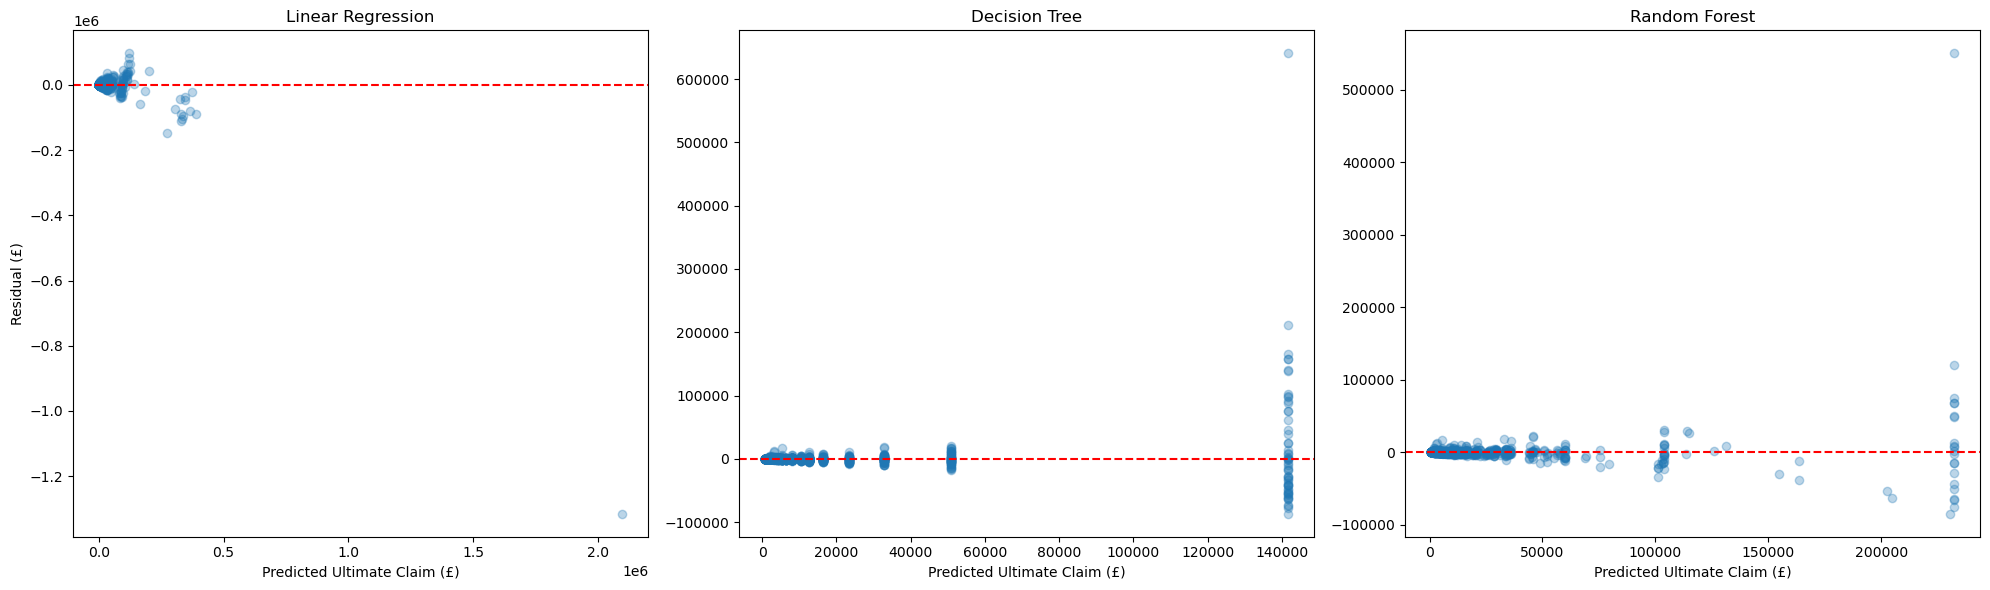

In [336]:

# Residuals
residuals_lr = y_true - y_pred_bc
residuals_tree = y_true - y_pred_tree_bc
residuals_rf = y_true - y_pred_rf_bc

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# Linear Regression
ax[0].scatter(y_pred_bc, residuals_lr, alpha=0.3)
ax[0].axhline(0, color="red", linestyle="--")
ax[0].set_title("Linear Regression")
ax[0].set_xlabel("Predicted Ultimate Claim (£)")
ax[0].set_ylabel("Residual (£)")

# Decision Tree
ax[1].scatter(y_pred_tree_bc, residuals_tree, alpha=0.3)
ax[1].axhline(0, color="red", linestyle="--")
ax[1].set_title("Decision Tree")
ax[1].set_xlabel("Predicted Ultimate Claim (£)")

# Random Forest
ax[2].scatter(y_pred_rf_bc, residuals_rf, alpha=0.3)
ax[2].axhline(0, color="red", linestyle="--")
ax[2].set_title("Random Forest")
ax[2].set_xlabel("Predicted Ultimate Claim (£)")

plt.tight_layout()
plt.show()


Residual Diagnostics were conducted to reveal systemic bias, heteroskedasticity and instability which are important in insurance claim severity modelling. The diagnosis confirms that random forest model not only achieves the lowest MAE and RMSE but also exhibits superior stability, reduced bias, and improved handling of large claims.

##### Linear Regression Model
* The residual plot for the linear regression model shows increasing dispersion of residuals as predicted claim size increases. This indicates systemic under-prediction for larger claims. The model provides a strong baseline but strugles to predict high severity claims accurately.

##### Decision Tree Model
* Here we see a step-like structure which captures non-linear effects better than linear regression model, However, still sensitive to high severity claims. 

##### Random Forest
* Residuals here are more evenly distributed around zero, showing improved performance for high severity and complex claims.


#### Best Performing Model (Tentatively) 
Random Forest Regressor appears to be the best performimg model because: 
1. it presents the lowest prediction error across all metrics
2. takes note of none linear effects



Multiple candidate models were evaluated for predicting ultimate claim severity, including a baseline intercept-only model, linear regression, decision tree regression, and random forest regression. All models were trained on the log-transformed target variable and predictions were bias-corrected and back-transformed to the original monetary scale prior to evaluation.

Model performance was assessed using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). The baseline model recorded an MAE of approximately £13.9k, serving as a benchmark for comparison.

Linear regression substantially improved performance, reducing MAE to approximately £4.1k. A decision tree model further improved predictive accuracy, achieving an MAE of approximately £3.6k and significantly reducing RMSE, indicating improved handling of large claims.

The random forest model delivered the strongest performance, achieving the lowest MAE (£2.3k) and RMSE (£16.0k). This represents an approximately 83% reduction in MAE relative to the baseline and a material improvement over both linear and single-tree models.

Residual diagnostics further confirmed that the random forest model exhibited reduced bias and improved stability across high-severity and complex claim segments.

Based on these results, the random forest model appears to be the best performing model due to its superior predictive accuracy, robustness, and ability to capture non-linear relationships inherent in insurance claim severity data.

# Train Advanced Model (XGBoost)
XGBoost will be trained to assess whether additional non-linear patterns beyond Random Forest could further improve claim severity predictions. 


In [337]:


xgb_pipe = Pipeline(
    steps=[
        ("model", XGBRegressor(
            objective="reg:squarederror",
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_pipe.fit(X_train, y_train)


Pipeline(steps=[('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=-1,
                              num_parallel_tree=None, ...))])

### Back-Transform to Real Values

In [339]:
# Predicted ultimate claim (log scale)
y_pred_log_xgb = xgb_pipe.predict(X_test)

# Predicted ultimate claim (£, no bias correction)
y_pred = np.expm1(y_pred_log_xgb)

# Actual ultimate claim (£)
y_true = np.expm1(y_test)


### Bias-Correction

In [340]:
# Predict on training data (log scale) to estimate residual variance
residuals_train = y_train - xgb_pipe.predict(X_train)
sigma2_xgb = residuals_train.var()

# Predict on test data (log scale)
y_pred_log_xgb = xgb_pipe.predict(X_test)

# Bias-corrected back-transformation to original £ scale
y_pred_xgb_bc = np.expm1(y_pred_log_xgb + 0.5 * sigma2_xgb)

# True values on original scale
y_true = np.expm1(y_test)


#### Performance Evaluation for XGBoost 

In [341]:
mae_xgb = mean_absolute_error(y_true, y_pred_xgb_bc)
rmse_xgb = np.sqrt(mean_squared_error(y_true, y_pred_xgb_bc))

print(mae_xgb)
print(rmse_xgb)


1697.5350141569334
9433.607214687609


### Compare with earlier Models

| Model                         | MAE (£)      | RMSE (£)     | Improvement vs Baseline (MAE) |
| ----------------------------- | ------------ | ------------ | ----------------------------- |
| **Baseline (intercept only)** | 13,900.93    | 38,001.37    | —                             |
| **Linear Regression**         | 4,061.74     | 35,345.43    | ~71% ↓                        |
| **Decision Tree**             | 3,606.60     | 21,804.40    | ~74% ↓                        |
| **Random Forest**             | 2,312.44     | 16,031.22    | ~83% ↓                        |
| **XGBoost**                   | **1,697.54** | **9,433.61** | **~88% ↓**                    |


XGBoost presents the lowest MAE and RMSE satisfactorily. the improvement over Random Forest is material not marginal, thereby confirming a stronger capture of non-linear structure. 

### Residual Diagnostics

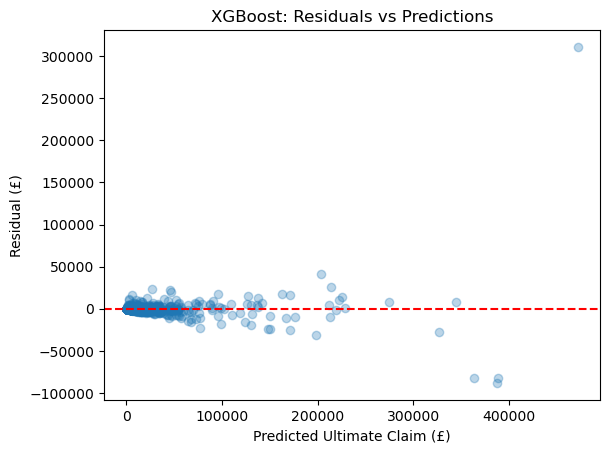

In [342]:

residuals_xgb = y_true - y_pred_xgb_bc

plt.scatter(y_pred_xgb_bc, residuals_xgb, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Ultimate Claim (£)")
plt.ylabel("Residual (£)")
plt.title("XGBoost: Residuals vs Predictions")
plt.show()


* Residual diagnostics for the XGBoost shows improved handling of high severity claims and stability compared to other models.
* Residuals are centered well around zero with no systematic upward and downward drift. this means on average, no material over or under- reserving. 


## Model Choice

##### Best Performing Model

XGBoost delivered the strongest predictive performance across all evaluated models, achieving an MAE of approximately £1.7k and an RMSE of £9.4k. This represents a substantial improvement over both Random Forest and simpler models, indicating improved capture of non-linear effects and enhanced tail risk performance. Further residual diagnostics and segment-level validation were conducted to confirm model stability prior to final selection

### No Hyperparameter Tunning 

Given the results of all models trained, hyperparameter tuning is not relevant for the following reasons:
* The result show a strong baseline and a clear linear benchmark
* Application of tree based models which detected non-linear patterns satisfactorily
* an XGBoost model that materially outperformed all others
* residual diagnostics showed no systamatic bias.  

# SHAP (SHapley Additive exPlanations)
SHAP will be applied to XGBoost to explain how each feature pushed a prediction upward or downward.

SHAP is improtant for this project for the following reasons:
* The project predicts ultimate claim amount which directly affects reserving adequacy, capital requirements and operational risks.
For this reason, accuracy alone is not sufficient. the model must be explainable, auditable and defensible. All these will be addressed by SHAP.

SHAP is applied to XGBoost because it is the best performing model that will be used to influence decisions. 


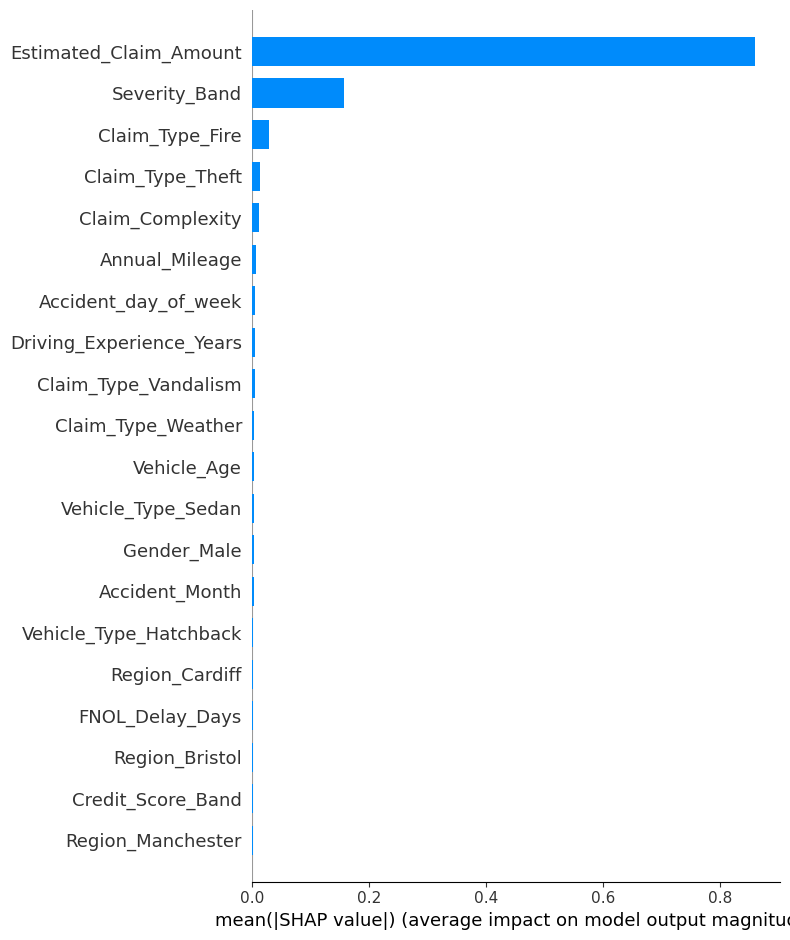

In [349]:

# Extract trained XGBoost model from pipeline
xgb_model = xgb_pipe.named_steps["model"]
# shap explainer
explainer = shap.TreeExplainer(xgb_model)
# compute shap values on test data
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=True
)



* Prediction is on the log scale as interpretation is more about relative contribution not monetary amount. 

* SHAP analysis indicates that the initial estimated claim amount is the dominant driver of ultimate claim severity, followed by injury severity and claim type. This aligns with insurance domain knowledge, where early financial assessments and physical damage severity are primary determinants of claim cost. Secondary factors such as claim complexity, mileage, and driving experience act as refinements, while demographic and geographic variables contribute minimally, supporting the fairness and robustness of the model.


### SHAP Dependence Plots
Shows how individual features's value influences the model's prediction. 

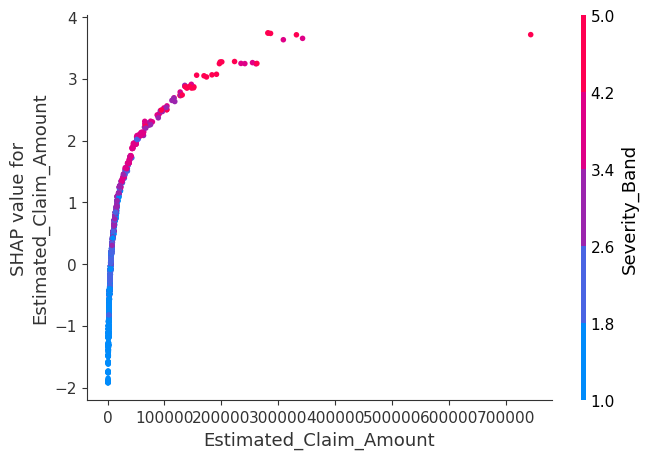

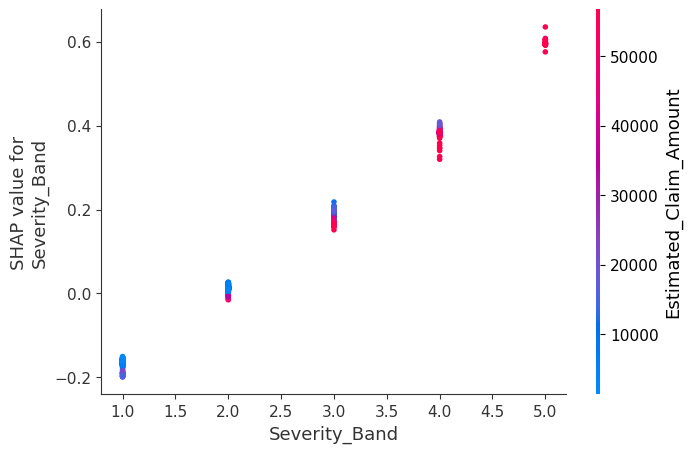

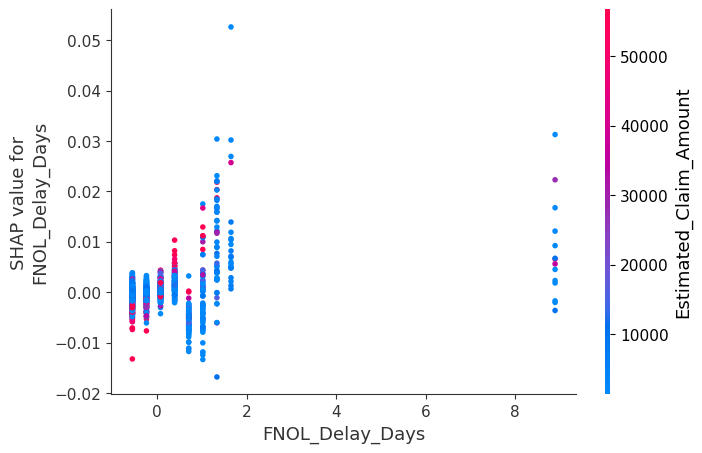

In [358]:

# Extract trained XGBoost model
xgb_model = xgb_pipe.named_steps["model"]

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values on test data
shap_values = explainer.shap_values(X_test)

# Most meaningful features for dependence plots
features_to_plot = [
    "Estimated_Claim_Amount",
    "Severity_Band",
    "FNOL_Delay_Days",
    
    
    
]

# dependence plots
for feature in features_to_plot:
    shap.dependence_plot(
        feature,
        shap_values,
        X_test,
        show=True
    )


SHAP dependence analysis focusing on three key drivers: Estimated Claim Amount, Severity Band, and FNOL Delay Days. These features jointly capture early financial exposure, physical claim severity, and behavioural escalation risk, providing an explanation of the model’s predictions.

* Red = High Severity
* Blue = Low Severity

##### Estimated Claim Amount
* As the estimated amount increases, SHAP values move strongly upward. this confirms that higher early eatimates increase predicted ultimate claim cost.
* In relation to severity band, the red points sit higher while the blue points sit lower. this implys that estimated claim amount leeds to higher predicted ultimate cost when severity is higher.
* The model does not blindly trust the estimate. it adjusts impact based on severity.
* The outliers at the far right still pushes predictions up but does not explode uncontrollably. this shows the model is stable.

##### Severity Band
* Each increase in severity band systematically increases predicted ultimate claim cost. This shows the model treats severity as an ordered risk driver. severity 1 reduces predicted ultimate claim cost while severity 3 - 5 increases predicted ultimate claim cost.
* However, the impact of severity is moderated by the estimated claim amount. severity defines the baseline risk while early financial estimate refines it. 

##### FNOL Delay Days
* This shows how much reporting delay pushes prediction upwards or downwards
* For immediate notifications ( 0 days), SHAP values are clustered tightly around zero or slightly negative. this means that early reporting allows controlled costs.
* For short delays (1 - 2 days) SHAP values become more positive and dispersed and delay starts to increase predicted ultimate costs. small delays matter
*  For longer days, SHAP values are clearly positive.
*  FNOL is a risk signal not just a timing issue which may be associated with fraud or legal complications. 

##### Claim Complexity
* Claim complexity was found to have a positive, effect on predicted severity, particularly for high-severity claims. However, its effect is secondary to severity and early financial estimates and is therefore discussed qualitatively rather than presented visually

# Model Explainability
Given the use of a non-linear ensemble model (XGBoost) for predicting ultimate claim severity, model interpretability is essential to ensure transparency, regulatory defensibility, and alignment with insurance domain knowledge. To achieve this, SHAP (SHapley Additive exPlanations) was applied to explain both global and local model behaviour.

#### Global Feature Importance

Global SHAP importance analysis indicates that the model’s predictions are driven primarily by:

Estimated Claim Amount

Severity Band

Claim Type (notably Fire-related claims)

The dominance of the initial estimated claim amount reflects established insurance practice, where early financial assessments encompases visible damage, and anticipated exposure. Severity band further captures the physical seriousness of the claim, while specific claim types introduce systematic differences in loss mechanisms and cost structures.

Demographic and geographic variables exhibit little influence, suggesting the model relies predominantly on claim-specific and operational factors rather than proxy attributes. This reduces concerns around unfair bias and strengthens the model’s governance profile.


#### Dependence Analysis for Key Drivers
While global importance identifies what matters most overall, dependence plots were used to explain how key features influence predictions across their value ranges. Three dependence plots were selected for detailed analysis based on interpretability, business relevance, and non-linear behaviour.

##### Estimated Claim Amount
The model shows that early claim estimates are a very strong indicator of how costly a claim will ultimately become. When the initial estimate increases, the expected final cost rises quickly at first. Once a claim is already recognised as large, further increases in the estimate add less new information. The impact of the estimate is even stronger for more serious claims, showing that early financial assessments work best when combined with severity information

#### Severity Band
Claim severity has a clear and consistent effect on final claim cost. Low-severity claims tend to settle for less, while higher-severity claims become progressively more expensive. The biggest cost increases occur for the most severe cases, confirming that catastrophic claims behave very differently from minor ones. This aligns closely with real claims experience.

#### FNOL Delay Days

How quickly a claim is reported matters. Claims reported on the same day generally do not see cost escalation. However, even short delays begin to increase expected claim costs, and longer delays significantly raise them. This effect is strongest for already expensive claims. In practice, this means delayed notification acts as a cost amplifier, reinforcing the importance of encouraging prompt claim reporting.

#### Features Excluded from Visual Explainability

Claim complexity and number of third parties do influence claim costs. However, they tend to reinforce what is already captured by claim severity and early cost estimates, rather than providing new insights on their own. Including them in detailed visual analysis would repeat the same message without adding much clarity.

By focusing only on the most informative drivers, the analysis is clear, avoids unnecessary detail, and keeps attention on the factors that most strongly explain why claim costs increase.

#### Summary and Governance Assessment

Overall, SHAP analysis demonstrates that the XGBoost model behaves in a manner consistent with insurance domain knowledge:

* Predictions are anchored to early financial exposure
* Physical severity drives structural cost escalation
* Behavioural factors such as notification delay amplify risk
* Non-linear interactions are captured appropriately
* Low-relevance demographic and geographic variables are down-weighted

These findings support the interpretability, robustness, and operational credibility of the final model. The explainability framework provides clear justification for model decisions and supports its suitability for use in reserving, triage, and early intervention contexts.